# Projeto de Portfólio — Previsão de Risco de Crédito

Notebook completo com pipeline reprodutível, comparação entre **Regressão Logística tunada** e **LightGBM tunado**, seleção de target, política de crédito calibrada, explicabilidade com **SHAP** e scoring de submissão.

## Objetivo
Construir uma solução completa de risco de crédito composta por:
1. **modelo preditivo** de inadimplência;
2. **política de crédito** baseada no score

Este notebook foi estruturado para:
- ser **reprodutível do zero**;
- explicar **as decisões de modelagem**;
- conectar **modelo → política → negócio**.


## 1. Pipeline completo reprodutível

**Bloco 1 - Setup**

Esse trecho faz 4 coisas principais:

1. Configuração do ambiente
2. Importação de bibliotecas
3. Definição de parâmetros globais
4. Setup de utilidades (paths + progresso)

In [ ]:
# Libs
from __future__ import annotations
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict
import requests
from io import BytesIO
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
)
from scipy.stats import loguniform
from sklearn.model_selection import ParameterGrid
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")
from tqdm.auto import tqdm
tqdm.pandas()

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

# Configurações globais
SEED = 42
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Definição da fonte dos dados
URL_BASE_CADASTRAL = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/base_cadastral.parquet"
URL_BASE_SUBMISSAO = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/base_submissao.parquet"
URL_HISTORICO_EMPRESTIMOS = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/historico_emprestimos.parquet"
URL_HISTORICO_PARCELAS = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/historico_parcelas.parquet"
URL_DICIONARIO = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/dicionario_dados.csv"


In [ ]:
# Imports adicionais para EDA, métricas e tuning
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, uniform

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 200)

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False


**Bloco 2 - Download e leitura dos dados**

Esse bloco faz download automático + leitura estruturada de todas as bases sem precisar:
* baixar manualmente
* configurar paths locais

In [ ]:
# =========================================================
# 1) DOWNLOAD E LEITURA DAS BASES
# =========================================================

'''
Função para leitura de um arquivo parquet direto da internet
Essa função permite leitura direta de arquivos parquet via HTTP, utilizando BytesIO para evitar persistência em disco e garantir eficiência e reprodutibilidade.
O que a função faz: faz download do arquivo via requests, lê diretamente em memória com BytesIO, converte para DataFrame com pd.read_parquet
'''
def read_parquet_from_url(url: str, nome_arquivo: str) -> pd.DataFrame:
    print(f"\nBaixando {nome_arquivo} ...")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    df = pd.read_parquet(BytesIO(response.content))
    print(f"{nome_arquivo} carregado | shape={df.shape}")
    return df

'''
Função para leitura de um arquivo csv
Essa função generaliza a leitura para diferentes formatos, mantendo o pipeline consistente
'''
def read_csv_from_url(url: str, nome_arquivo: str, sep: str = ";") -> pd.DataFrame:
    print(f"\nBaixando {nome_arquivo} ...")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    df = pd.read_csv(BytesIO(response.content), sep=sep)
    print(f"{nome_arquivo} carregado | shape={df.shape}")
    return df

'''
Função para desacoplar a origem dos dados e a lógica do código
Esta função centraliza as fontes, facilita manutenção e evita código duplicado
'''
def read_inputs():
    arquivos = [
        ("base_cadastral", URL_BASE_CADASTRAL, "parquet"),
        ("base_submissao", URL_BASE_SUBMISSAO, "parquet"),
        ("historico_emprestimos", URL_HISTORICO_EMPRESTIMOS, "parquet"),
        ("historico_parcelas", URL_HISTORICO_PARCELAS, "parquet"),
        ("dicionario_dados", URL_DICIONARIO, "csv"),
    ]

    resultados = {}
    for nome, url, tipo in tqdm(arquivos, desc="Lendo arquivos", unit="arquivo"):
        if tipo == "parquet":
            resultados[nome] = read_parquet_from_url(url, nome)
        else:
            resultados[nome] = read_csv_from_url(url, nome, sep=";")

    return (
        resultados["base_cadastral"],
        resultados["base_submissao"],
        resultados["historico_emprestimos"],
        resultados["historico_parcelas"],
        resultados["dicionario_dados"],
    )

**Bloco 3 - Preparo Básico**

Esse bloco faz padronização + tipagem + criação de variáveis básicas. Por meio da transformação dos dados “crus” em dados utilizáveis e consistentes:
1. garante que datas são datas
2. números são números
3. cria features iniciais (idade, renda mensal)

In [ ]:
# =========================================================
# 2) PREPARO BÁSICO
# =========================================================

'''
Função para receber as bases de dados e retornar as mesmas tratadas
Essa função centraliza o pré-processamento inicial garantindo consistência entre todas as bases.
'''
def preprocess_inputs(
    base_cadastral: pd.DataFrame,
    base_submissao: pd.DataFrame,
    historico_emprestimos: pd.DataFrame,
    historico_parcelas: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    print("\nIniciando preprocessamento básico...")

    # Cópia das bases (para evitar efeitos colaterais nas bases originais)
    bc = base_cadastral.copy()
    bs = base_submissao.copy()
    he = historico_emprestimos.copy()
    hp = historico_parcelas.copy()

    # agrupa todas as bases para aplicar transformações em loop (evita repetições de códigos)
    dfs = [
        ("base_cadastral", bc),
        ("base_submissao", bs),
        ("historico_emprestimos", he),
        ("historico_parcelas", hp),
    ]

    # todas as colunas que deveriam ser datas
    date_cols = [
        "data_nascimento",
        "data_solicitacao",
        "data_decisao",
        "data_liberacao",
        "data_primeiro_vencimento",
        "data_ultimo_vencimento_original",
        "data_ultimo_vencimento",
        "data_encerramento",
        "data_prevista_pagamento",
        "data_real_pagamento",
    ]

    # todas as colunas que deveriam ser números
    numeric_cols = [
        "qtd_filhos",
        "qtd_membros_familia",
        "renda_anual",
        "nota_regiao_cliente",
        "nota_regiao_cliente_cidade",
        "hora_solicitacao",
        "valor_credito",
        "valor_bem",
        "valor_parcela",
        "valor_solicitado",
        "valor_entrada",
        "percentual_entrada",
        "qtd_parcelas_planejadas",
        "taxa_juros_padrao",
        "taxa_juros_promocional",
        "numero_parcela",
        "valor_previsto_parcela",
        "valor_pago_parcela",
        "versao_parcela",
    ]

    '''
    conversão de datas para o formato datetime
    conversão robusta de datas com tratamento de erro para garantir consistência sem interromper o pipeline
    '''
    for nome_df, df in tqdm(dfs, desc="Convertendo datas", unit="base"):
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")

    '''
    conversão numérica (garante que valores são números)
    padronização das variáveis numéricas garantindo compatibilidade com modelos e evitando inconsistências de tipo
    '''
    for nome_df, df in tqdm(dfs, desc="Convertendo numéricos", unit="base"):
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    '''
    transformação da renda anual em renda mensal
    criação de uma proxy de renda mensal para melhor representar a capacidade de pagamento do cliente
    modelos de crédito trabalham melhor com fluxo mensal e capacidade de pagamento mensal
    '''
    if "renda_anual" in bc.columns:
        bc["renda_mensal_proxy"] = bc["renda_anual"] / 12.0

    '''
    cálculo da idade (variável clássica de crédito e com possibilidade de correlação com risco)
    a idade foi derivada para capturar perfil demográfico do cliente, relevante para análise de risco
    '''
    if "data_nascimento" in bc.columns:
        ref_date = pd.Timestamp.today().normalize()
        bc["idade"] = ((ref_date - bc["data_nascimento"]).dt.days / 365.25).astype(float)

    print("Preprocessamento básico concluído.")
    return bc, bs, he, hp

**Bloco 4 - Construção das variáveis target**

Essa função pega o histórico de parcelas e transforma informações no nível da parcela em targets no nível do contrato. Em outras palavras,
* entrada: várias linhas por contrato, uma por parcela
* saída: uma linha por contrato, com indicadores de inadimplência e comportamento de pagamento

Para cada contrato, passa a ter:
* targets binários
* maior atraso observado
* atraso inédito
* número de parcelas observadas
* valor total previsto
* valor total pago

In [ ]:
# =========================================================
# 3A) CANDIDATOS DE TARGET
# Construção genérica de alvos de inadimplência
# =========================================================

def build_candidate_target(
    hp: pd.DataFrame,
    dpd_threshold: int,
    mob_window: int,
    analysis_date: pd.Timestamp
) -> pd.DataFrame:
    """
    Constrói um target candidato no nível do contrato.

    Parâmetros
    ----------
    hp : pd.DataFrame
        Base de histórico de parcelas.
    dpd_threshold : int
        Threshold de atraso em dias (ex.: 15, 30, 60).
    mob_window : int
        Janela de parcelas observadas (ex.: 3 ou 6 primeiras parcelas).
    analysis_date : pd.Timestamp
        Data analítica usada para calcular DPD de parcelas ainda não pagas.

    Retorno
    -------
    pd.DataFrame
        Base agregada por id_cliente e id_contrato com:
        - target candidato
        - elegibilidade
        - métricas auxiliares do contrato
    """

    df = hp.copy()

    # -----------------------------------------------------
    # 1) Ordenação das parcelas
    # -----------------------------------------------------
    sort_cols = ["id_contrato", "numero_parcela"]
    if "versao_parcela" in df.columns:
        sort_cols.append("versao_parcela")

    df = df.sort_values(sort_cols).reset_index(drop=True)

    # -----------------------------------------------------
    # 2) Cálculo do DPD com data analítica
    # Se a parcela foi paga, usa data_real_pagamento.
    # Se não foi paga, usa analysis_date.
    # -----------------------------------------------------
    analysis_date = pd.to_datetime(analysis_date)

    ref_date = df["data_real_pagamento"].fillna(analysis_date)
    df["dpd"] = (ref_date - df["data_prevista_pagamento"]).dt.days.clip(lower=0)

    # -----------------------------------------------------
    # 3) Flag do evento dentro da janela definida
    # Ex.: mob_window=3 e dpd_threshold=30 => EVER30MOB03
    # -----------------------------------------------------
    flag_name = f"flag_ever{dpd_threshold}mob{mob_window:02d}"
    target_name = f"target_ever{dpd_threshold}mob{mob_window:02d}"
    eligible_name = f"eligible_ever{dpd_threshold}mob{mob_window:02d}"

    df[flag_name] = (
        (df["numero_parcela"] <= mob_window) &
        (df["dpd"] >= dpd_threshold)
    ).astype(int)

    # -----------------------------------------------------
    # 4) Agregação por contrato
    # -----------------------------------------------------
    contract_target = (
        df.groupby(["id_cliente", "id_contrato"], as_index=False)
        .agg(
            **{
                target_name: (flag_name, "max"),
                "max_dpd_contrato": ("dpd", "max"),
                "mean_dpd_contrato": ("dpd", "mean"),
                "qtd_parcelas_observadas": ("numero_parcela", "max"),
                "valor_previsto_total": ("valor_previsto_parcela", "sum"),
                "valor_pago_total": ("valor_pago_parcela", "sum"),
                "dt_primeiro_vencimento": ("data_prevista_pagamento", "min"),
                "dt_ultimo_vencimento_observado": ("data_prevista_pagamento", "max"),
            }
        )
    )

    # -----------------------------------------------------
    # 5) Elegibilidade / maturação
    # O contrato só é elegível se teve pelo menos 'mob_window'
    # parcelas observadas.
    # -----------------------------------------------------
    contract_target[eligible_name] = (
        contract_target["qtd_parcelas_observadas"] >= mob_window
    ).astype(int)

    # -----------------------------------------------------
    # 6) Percentual pago do contrato
    # -----------------------------------------------------
    contract_target["pct_pago_contrato"] = (
        contract_target["valor_pago_total"] /
        contract_target["valor_previsto_total"].replace({0: np.nan})
    )

    # -----------------------------------------------------
    # 7) Metadados do candidato
    # -----------------------------------------------------
    contract_target["dpd_threshold"] = dpd_threshold
    contract_target["mob_window"] = mob_window
    contract_target["target_name"] = target_name

    return contract_target

In [ ]:
# =========================================================
# 3B) COMPARAÇÃO DOS CANDIDATOS DE TARGET
# Cobertura, prevalência, estabilidade temporal e separabilidade
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

def ks_statistic(y_true, y_score):
    """
    Calcula KS de forma simples.
    """
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score")
    tmp["cum_bad"] = (tmp["y"] == 1).cumsum() / max((tmp["y"] == 1).sum(), 1)
    tmp["cum_good"] = (tmp["y"] == 0).cumsum() / max((tmp["y"] == 0).sum(), 1)
    return np.max(np.abs(tmp["cum_bad"] - tmp["cum_good"]))


def evaluate_candidate_target(
    base_features: pd.DataFrame,
    target_df: pd.DataFrame,
    target_col: str,
    eligible_col: str,
    date_col: str,
    id_cols=("id_cliente", "id_contrato"),
    min_rows_for_model: int = 300
):
    """
    Avalia um candidato de target com base em:
    - cobertura elegível
    - prevalência
    - estabilidade temporal
    - separabilidade via baseline simples (Logística)
    """

    # -----------------------------------------------------
    # 1) Join entre features e target
    # -----------------------------------------------------
    merge_cols = list(id_cols)
    keep_cols = merge_cols + [target_col, eligible_col]

    df = base_features.merge(
        target_df[keep_cols],
        on=merge_cols,
        how="inner"
    )

    # Mantém apenas contratos elegíveis
    df = df[df[eligible_col] == 1].copy()

    # -----------------------------------------------------
    # 2) Métricas descritivas
    # -----------------------------------------------------
    coverage = df.shape[0] / max(base_features.shape[0], 1)
    prevalence = df[target_col].mean() if df.shape[0] > 0 else np.nan

    # Bad rate por safra/data
    bad_rate_by_time = (
        df.groupby(date_col)[target_col]
        .mean()
        .reset_index(name="bad_rate")
        .sort_values(date_col)
    )

    temporal_std = bad_rate_by_time["bad_rate"].std() if bad_rate_by_time.shape[0] > 1 else np.nan
    temporal_min = bad_rate_by_time["bad_rate"].min() if bad_rate_by_time.shape[0] > 0 else np.nan
    temporal_max = bad_rate_by_time["bad_rate"].max() if bad_rate_by_time.shape[0] > 0 else np.nan

    # -----------------------------------------------------
    # 3) Separabilidade com baseline simples
    # Aqui a ideia é usar poucas features numéricas para ver
    # se o target é modelável. Não é ainda o modelo final.
    # -----------------------------------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    forbidden_cols = list(id_cols) + [target_col, eligible_col]
    feature_cols = [c for c in numeric_cols if c not in forbidden_cols]

    # remove colunas muito vazias
    feature_cols = [c for c in feature_cols if df[c].notna().mean() >= 0.7]

    auc = np.nan
    pr_auc = np.nan
    ks = np.nan

    if (df.shape[0] >= min_rows_for_model) and (len(feature_cols) > 0) and (df[target_col].nunique() == 2):
        model_df = df[feature_cols + [target_col]].copy()

        # imputação simples para baseline
        for col in feature_cols:
            model_df[col] = model_df[col].fillna(model_df[col].median())

        X = model_df[feature_cols]
        y = model_df[target_col]

        model = LogisticRegression(max_iter=1000, class_weight="balanced")
        model.fit(X, y)

        y_score = model.predict_proba(X)[:, 1]

        auc = roc_auc_score(y, y_score)
        pr_auc = average_precision_score(y, y_score)
        ks = ks_statistic(y, y_score)

    summary = pd.DataFrame([{
        "target_col": target_col,
        "eligible_col": eligible_col,
        "n_eligible": df.shape[0],
        "coverage": coverage,
        "prevalence": prevalence,
        "temporal_std_bad_rate": temporal_std,
        "temporal_min_bad_rate": temporal_min,
        "temporal_max_bad_rate": temporal_max,
        "auc_baseline": auc,
        "pr_auc_baseline": pr_auc,
        "ks_baseline": ks
    }])

    return summary, bad_rate_by_time, df

In [ ]:
# =========================================================
# 3C) TARGETS COM MATURAÇÃO, DATA ANALÍTICA E CANDIDATOS
# =========================================================

def infer_analysis_date(he: pd.DataFrame, hp: pd.DataFrame) -> pd.Timestamp:
    """
    Define uma data analítica conservadora para medir atraso em aberto.
    Em produção, o ideal é usar a data real de observação da carteira.
    """
    candidates = []

    for col in ["data_decisao", "data_liberacao", "data_encerramento"]:
        if col in he.columns:
            candidates.append(pd.to_datetime(he[col], errors="coerce").max())

    for col in ["data_prevista_pagamento", "data_real_pagamento"]:
        if col in hp.columns:
            candidates.append(pd.to_datetime(hp[col], errors="coerce").max())

    candidates = [c for c in candidates if pd.notna(c)]

    if not candidates:
        raise ValueError("Não foi possível inferir analysis_date a partir das tabelas.")

    return max(candidates)


def prepare_installment_base(
    hp: pd.DataFrame,
    analysis_date: pd.Timestamp | None = None,
) -> pd.DataFrame:
    """
    Prepara a base de parcelas com:
    - ordenação correta
    - DPD em aberto calculado até a data analítica
    - flag de maturação da parcela
    """
    df = hp.copy()

    sort_cols = ["id_contrato", "numero_parcela"]
    if "versao_parcela" in df.columns:
        sort_cols.append("versao_parcela")

    df = df.sort_values(sort_cols).reset_index(drop=True)

    if analysis_date is None:
        analysis_date = pd.to_datetime(df["data_prevista_pagamento"], errors="coerce").max()

    analysis_date = pd.Timestamp(analysis_date)

    due_date = pd.to_datetime(df["data_prevista_pagamento"], errors="coerce")
    pay_date = pd.to_datetime(df["data_real_pagamento"], errors="coerce")

    # Se não pagou, mede atraso até a data analítica
    ref_date = pay_date.fillna(analysis_date)

    df["dpd_open"] = (ref_date - due_date).dt.days.clip(lower=0)

    # Parcela só pode gerar evento se já venceu até a analysis_date
    df["parcela_madura"] = (due_date <= analysis_date).astype(int)

    df["analysis_date"] = analysis_date

    return df


def build_candidate_target(
    df_parcelas: pd.DataFrame,
    dpd_threshold: int,
    mob_window: int,
    target_label: str | None = None,
) -> pd.DataFrame:
    """
    Constrói um target candidato no nível do contrato.

    Exemplo:
    - dpd_threshold=15, mob_window=3  -> EVER15MOB03
    - dpd_threshold=30, mob_window=3  -> EVER30MOB03
    - dpd_threshold=60, mob_window=6  -> OVER60MOB06 (conceitualmente)
    """

    df = df_parcelas.copy()

    if target_label is None:
        target_label = f"ever{dpd_threshold}mob{mob_window:02d}"

    flag_col = f"flag_{target_label}"
    target_col = f"target_{target_label}"
    eligible_col = f"eligible_{target_label}"

    # Evento só conta dentro da janela e com parcela madura
    df[flag_col] = (
        (df["numero_parcela"] <= mob_window) &
        (df["dpd_open"] >= dpd_threshold) &
        (df["parcela_madura"] == 1)
    ).astype(int)

    out = (
        df.groupby(["id_cliente", "id_contrato"], as_index=False)
        .agg(
            **{
                target_col: (flag_col, "max"),
                "max_dpd_contrato": ("dpd_open", "max"),
                "mean_dpd_contrato": ("dpd_open", "mean"),
                "qtd_parcelas_observadas": ("numero_parcela", "max"),
                "qtd_parcelas_maduras": ("parcela_madura", "sum"),
                "valor_previsto_total": ("valor_previsto_parcela", "sum"),
                "valor_pago_total": ("valor_pago_parcela", "sum"),
                "analysis_date": ("analysis_date", "max"),
            }
        )
    )

    out["pct_pago_contrato"] = (
        out["valor_pago_total"] /
        out["valor_previsto_total"].replace({0: np.nan})
    )

    # Elegibilidade formal: precisa ter pelo menos 'mob_window' parcelas maduras
    out[eligible_col] = (out["qtd_parcelas_maduras"] >= mob_window).astype(int)

    out["target_name"] = target_label
    out["dpd_threshold"] = dpd_threshold
    out["mob_window"] = mob_window

    return out


def build_all_candidate_targets(
    hp: pd.DataFrame,
    he: pd.DataFrame | None = None,
    candidate_specs: list[dict] | None = None,
    analysis_date: pd.Timestamp | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Gera vários candidatos de target.
    """
    if analysis_date is None:
        if he is not None:
            analysis_date = infer_analysis_date(he, hp)
        else:
            analysis_date = pd.to_datetime(hp["data_prevista_pagamento"], errors="coerce").max()

    df_parcelas = prepare_installment_base(hp, analysis_date=analysis_date)

    if candidate_specs is None:
        candidate_specs = [
            {"label": "fpd", "dpd_threshold": 1, "mob_window": 1},
            {"label": "ever15mob03", "dpd_threshold": 15, "mob_window": 3},
            {"label": "ever30mob03", "dpd_threshold": 30, "mob_window": 3},
            {"label": "ever45mob03", "dpd_threshold": 45, "mob_window": 3},
            {"label": "over60mob06", "dpd_threshold": 60, "mob_window": 6},
        ]

    outputs = {}

    for spec in candidate_specs:
        label = spec["label"]
        outputs[label] = build_candidate_target(
            df_parcelas=df_parcelas,
            dpd_threshold=spec["dpd_threshold"],
            mob_window=spec["mob_window"],
            target_label=label
        )

    print(f"analysis_date={analysis_date.date()} | candidatos gerados={list(outputs.keys())}")
    return outputs


def compare_target_candidates(
    candidate_targets: dict[str, pd.DataFrame],
    he: pd.DataFrame,
    date_col: str = "data_decisao",
) -> pd.DataFrame:
    """
    Compara cobertura, prevalência e estabilidade temporal dos candidatos.
    """
    base_ref = he[["id_cliente", "id_contrato", date_col]].copy()
    base_ref["safra"] = pd.to_datetime(base_ref[date_col], errors="coerce").dt.to_period("M").dt.to_timestamp()

    rows = []

    for label, target_df in candidate_targets.items():
        target_col = f"target_{label}"
        eligible_col = f"eligible_{label}"

        tmp = base_ref.merge(
            target_df[["id_cliente", "id_contrato", target_col, eligible_col]],
            on=["id_cliente", "id_contrato"],
            how="left"
        ).copy()

        cobertura = tmp[eligible_col].fillna(0).mean()

        elegiveis = tmp.loc[tmp[eligible_col] == 1].copy()
        prevalencia = elegiveis[target_col].mean() if len(elegiveis) else np.nan

        bad_rate_safra = (
            elegiveis.groupby("safra")[target_col]
            .mean()
            .reset_index(name="bad_rate")
            if len(elegiveis) else pd.DataFrame(columns=["safra", "bad_rate"])
        )

        safra_std = bad_rate_safra["bad_rate"].std() if len(bad_rate_safra) else np.nan
        safra_min = bad_rate_safra["bad_rate"].min() if len(bad_rate_safra) else np.nan
        safra_max = bad_rate_safra["bad_rate"].max() if len(bad_rate_safra) else np.nan

        rows.append({
            "target": label,
            "contratos_total": len(tmp),
            "contratos_elegiveis": len(elegiveis),
            "cobertura_elegivel": cobertura,
            "bad_rate": prevalencia,
            "std_bad_rate_por_safra": safra_std,
            "min_bad_rate_por_safra": safra_min,
            "max_bad_rate_por_safra": safra_max,
        })

    out = pd.DataFrame(rows)

    if not out.empty:
        out = out.sort_values(
            ["cobertura_elegivel", "bad_rate"],
            ascending=[False, False]
        )

    return out


def choose_recommended_target(target_comparison: pd.DataFrame) -> str:
    """
    Heurística simples e auditável:
    - prioriza boa cobertura
    - evita target excessivamente raro
    - favorece estabilidade temporal
    """

    df = target_comparison.copy()

    # penaliza targets raros demais
    df["bad_rate_ajustado"] = df["bad_rate"].where(
        (df["bad_rate"] >= 0.03) & (df["bad_rate"] <= 0.30),
        other=0
    )

    # quanto menor a std do bad rate por safra, melhor
    std_fill = df["std_bad_rate_por_safra"].max()
    if pd.isna(std_fill):
        std_fill = 0

    df["score"] = (
        0.50 * df["cobertura_elegivel"].fillna(0)
        + 0.30 * df["bad_rate_ajustado"].fillna(0)
        - 0.20 * df["std_bad_rate_por_safra"].fillna(std_fill)
    )

    return df.sort_values("score", ascending=False).iloc[0]["target"]

**Bloco 5 - Montagem da base de treino**

Essa função faz transformar histórico de contratos em uma base onde cada linha representa uma decisão de crédito, usando apenas informações disponíveis até aquele momento

* Palavra-chave: ponto-no-tempo (point-in-time)
* Evita: data leakage

Em resumo, o bloco de códigos:
* monta a base de treino real do mercado
* incorpora a target ao histórico de contratos
* cria features históricas sem olhar o futuro
* adiciona variãveis financeiras e cadastrais
* traduz conceitos clássicos de risco de crédito em features modeláveis

In [ ]:
# =========================================================
# 4A) BASE DE TREINO PONTO-NO-TEMPO
#    (adaptada ao target escolhido)
# =========================================================

def build_train_base_v2(
    he: pd.DataFrame,
    bc: pd.DataFrame,
    contract_target: pd.DataFrame,
    target_col: str,
    eligible_col: str,
    historical_target_cols: list[str] | None = None,
) -> pd.DataFrame:
    print("\nConstruindo base de treino (v2)...")

    if historical_target_cols is None:
        historical_target_cols = []

    # -----------------------------------------------------
    # 1) Junta contratos com target escolhido
    # -----------------------------------------------------
    df = he.copy()
    df = df.merge(contract_target, on=["id_cliente", "id_contrato"], how="left")

    # Mantém só contratos elegíveis para o target final
    if eligible_col in df.columns:
        df = df[df[eligible_col] == 1].copy()

    # Ordenação temporal correta por cliente
    df = df.sort_values(["id_cliente", "data_decisao", "id_contrato"]).reset_index(drop=True)

    grp = df.groupby("id_cliente", group_keys=False)

    # -----------------------------------------------------
    # 2) Features básicas de histórico
    # -----------------------------------------------------
    df["prev_num_contracts"] = grp.cumcount()
    df["prev_days_since_last_application"] = grp["data_decisao"].diff().dt.days

    # -----------------------------------------------------
    # 3) Features históricas gerais do contrato
    # -----------------------------------------------------
    hist_cols = [
        target_col,                 # target principal escolhido
        "max_dpd_contrato",
        "mean_dpd_contrato",
        "pct_pago_contrato",
        "valor_credito",
        "valor_solicitado",
        "valor_parcela",
        "qtd_parcelas_planejadas",
    ]

    # adiciona targets auxiliares históricos, se existirem
    for col in historical_target_cols:
        if col not in hist_cols:
            hist_cols.append(col)

    for col in hist_cols:
        if col in df.columns:
            df[f"prev_mean_{col}"] = grp[col].transform(lambda s: s.shift(1).expanding().mean())
            df[f"prev_max_{col}"] = grp[col].transform(lambda s: s.shift(1).expanding().max())
            df[f"prev_last_{col}"] = grp[col].shift(1)

    # -----------------------------------------------------
    # 4) Features de curto prazo para o target principal
    # -----------------------------------------------------
    if target_col in df.columns:
        df["prev_bad_rate_last3"] = grp[target_col].transform(
            lambda s: s.shift(1).rolling(3, min_periods=1).mean()
        )

    if "max_dpd_contrato" in df.columns:
        df["prev_avg_max_dpd_last3"] = grp["max_dpd_contrato"].transform(
            lambda s: s.shift(1).rolling(3, min_periods=1).mean()
        )

    # -----------------------------------------------------
    # 5) Histórico dentro do mesmo tipo de contrato
    # -----------------------------------------------------
    if "tipo_contrato" in df.columns and target_col in df.columns:
        df["prev_bad_same_tipo_contrato"] = (
            df.groupby(["id_cliente", "tipo_contrato"])[target_col]
            .transform(lambda s: s.shift(1).expanding().mean())
        )

    # -----------------------------------------------------
    # 6) Features do contrato atual
    # -----------------------------------------------------
    if "valor_credito" in df.columns and "valor_solicitado" in df.columns:
        df["pct_valor_aprovado_sobre_solicitado"] = (
            df["valor_credito"] / df["valor_solicitado"].replace({0: np.nan})
        )

    if "valor_entrada" in df.columns and "valor_bem" in df.columns:
        if "valor_credito" in df.columns:
            df["ltv_proxy"] = df["valor_credito"] / df["valor_bem"].replace({0: np.nan})
        else:
            df["ltv_proxy"] = np.nan

        df["entrada_sobre_bem"] = (
            df["valor_entrada"] / df["valor_bem"].replace({0: np.nan})
        )

    # -----------------------------------------------------
    # 7) Merge com base cadastral
    # -----------------------------------------------------
    base = df.merge(bc, on="id_cliente", how="left")

    if "renda_mensal_proxy" in base.columns and "valor_parcela" in base.columns:
        base["parcela_sobre_renda"] = (
            base["valor_parcela"] / base["renda_mensal_proxy"].replace({0: np.nan})
        )

    if "renda_anual" in base.columns and "valor_credito" in base.columns:
        base["credito_sobre_renda_anual"] = (
            base["valor_credito"] / base["renda_anual"].replace({0: np.nan})
        )

    print(f"Base de treino pronta | shape={base.shape}")
    return base

In [ ]:
# =========================================================
# 4B) EDA DE CRÉDITO E AUDITORIA DE FEATURES
#     (adaptado ao target escolhido)
# =========================================================

def make_modeling_base_v3(
    he: pd.DataFrame,
    bc: pd.DataFrame,
    contract_target_final: pd.DataFrame,
    target_col: str,
    eligible_col: str,
    historical_target_cols: list[str] | None = None,
):
    """
    Monta a base de modelagem já alinhada ao target escolhido
    na etapa de comparação de candidatos.
    """
    train_base = build_train_base_v2(
        he=he,
        bc=bc,
        contract_target=contract_target_final,
        target_col=target_col,
        eligible_col=eligible_col,
        historical_target_cols=historical_target_cols or []
    ).copy()

    # segurança adicional
    if eligible_col in train_base.columns:
        train_base = train_base.loc[train_base[eligible_col] == 1].copy()

    return train_base, target_col, eligible_col


def eda_missing_report(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    out = pd.DataFrame({
        "coluna": df.columns,
        "missing_pct": df.isna().mean().values,
        "n_unique": df.nunique(dropna=False).values,
        "dtype": df.dtypes.astype(str).values,
    }).sort_values("missing_pct", ascending=False)

    return out.head(top_n)


def plot_target_by_vintage(df: pd.DataFrame, date_col: str, target_col: str, title: str = ""):
    tmp = df[[date_col, target_col]].copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors="coerce")
    tmp = tmp.dropna(subset=[date_col, target_col])

    tmp["safra"] = tmp[date_col].dt.to_period("M").dt.to_timestamp()
    agg = tmp.groupby("safra")[target_col].agg(["mean", "size"]).reset_index()

    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(agg["safra"], agg["mean"], marker="o")
    ax1.set_title(title or f"Bad rate por safra - {target_col}")
    ax1.set_ylabel("bad rate")
    ax1.grid(True, alpha=0.3)
    plt.show()

    display(agg.rename(columns={"mean": "bad_rate", "size": "qtd_contratos"}))


def plot_numeric_by_target(df: pd.DataFrame, cols: list[str], target_col: str):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print("Nenhuma coluna numérica encontrada para plot.")
        return

    for col in cols:
        tmp = df[[col, target_col]].copy()
        tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

        if tmp.empty:
            continue

        plt.figure(figsize=(8, 4))
        for classe in sorted(tmp[target_col].dropna().unique()):
            serie = tmp.loc[tmp[target_col] == classe, col].clip(
                lower=tmp[col].quantile(0.01),
                upper=tmp[col].quantile(0.99)
            )
            serie.plot(kind="kde", label=f"{target_col}={classe}")

        plt.title(f"Distribuição de {col} por target")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


def leakage_audit(train_df: pd.DataFrame, target_col: str | None = None) -> pd.DataFrame:
    """
    Auditoria simples de possível leakage.
    Marca colunas potencialmente problemáticas por nome.
    """
    suspicious_patterns = [
        "pago", "encerr", "dpd", "target", "real_pag", "atras", "vencimento"
    ]

    rows = []
    for c in train_df.columns:
        flagged = any(p in c.lower() for p in suspicious_patterns)

        # a própria target não é leakage "indevido", então só marcamos separadamente
        is_target = (c == target_col)

        rows.append({
            "feature": c,
            "eh_target": is_target,
            "suspeita_leakage": flagged and not is_target,
            "missing_pct": train_df[c].isna().mean(),
            "dtype": str(train_df[c].dtype),
        })

    return pd.DataFrame(rows).sort_values(
        ["suspeita_leakage", "missing_pct"],
        ascending=[False, False]
    )


def feature_summary_by_target(df: pd.DataFrame, target_col: str, cols: list[str]) -> pd.DataFrame:
    """
    Resumo tabular simples das features por classe do target.
    """
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.DataFrame()

    rows = []
    for col in cols:
        tmp = df[[col, target_col]].replace([np.inf, -np.inf], np.nan).dropna()
        if tmp.empty:
            continue

        grp = tmp.groupby(target_col)[col].agg(["mean", "median", "std"]).reset_index()
        grp["feature"] = col
        rows.append(grp)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def run_eda_pack_v2(
    train_df: pd.DataFrame,
    target_col: str,
    date_col: str = "data_decisao",
    numeric_candidates: list[str] | None = None,
):
    print("\n===== EDA | Missingness =====")
    display(eda_missing_report(train_df, top_n=25))

    print("\n===== EDA | Auditoria de possível leakage =====")
    display(leakage_audit(train_df, target_col=target_col).head(40))

    if date_col in train_df.columns:
        print("\n===== EDA | Bad rate por safra =====")
        plot_target_by_vintage(train_df, date_col, target_col)

    if numeric_candidates is None:
        numeric_candidates = [
            "valor_credito",
            "valor_parcela",
            "idade_anos",
            "razao_parcela_credito",
            "prev_num_contracts",
            "prev_bad_rate_last3",
            "prev_avg_max_dpd_last3",
            "parcela_sobre_renda",
            "credito_sobre_renda_anual",
            "ltv_proxy",
        ]

    numeric_candidates = [c for c in numeric_candidates if c in train_df.columns]

    if numeric_candidates:
        print("\n===== EDA | Resumo tabular por target =====")
        display(feature_summary_by_target(train_df, target_col, numeric_candidates[:8]))

        print("\n===== EDA | Distribuições por target =====")
        plot_numeric_by_target(train_df, numeric_candidates[:4], target_col)

**Bloco 6 - Montagem da base de submissão**

Essa função cria uma base de features no nível do cliente, usando todo o histórico disponível até agora, para prever novos casos. Este bloco constrói a base final de scoring, isto é, a base que será usada para gerar as probabilidades para os contratos da `base_submissao`.

Enquanto o bloco anterior montava a base de treino contrato a contrato, este bloco faz a versão equivalente para o presente => pega os clientes que estão em análise agora e resume todo o histõrico passado deles em features que o modelo consiga usar.

In [ ]:
# =========================================================
# 5) BASE DE SUBMISSÃO
#    (adaptada ao target escolhido)
# =========================================================

def build_submission_base_v2(
    bs: pd.DataFrame,
    he: pd.DataFrame,
    bc: pd.DataFrame,
    contract_target_final: pd.DataFrame,
    target_col: str,
    historical_target_cols: list[str] | None = None,
) -> pd.DataFrame:
    print("\nConstruindo base de submissão (v2)...")

    if historical_target_cols is None:
        historical_target_cols = []

    # -----------------------------------------------------
    # 1) Reconstrução do histórico do cliente com target final
    # -----------------------------------------------------
    hist = he.copy().merge(
        contract_target_final,
        on=["id_cliente", "id_contrato"],
        how="left"
    )

    hist = hist.sort_values(
        ["id_cliente", "data_decisao", "id_contrato"]
    ).reset_index(drop=True)

    # -----------------------------------------------------
    # 2) Dicionário de agregação do histórico
    # -----------------------------------------------------
    agg_dict = {
        "prev_num_contracts": ("id_contrato", "nunique"),
        "prev_last_decision_date": ("data_decisao", "max"),

        # target principal escolhido
        f"prev_mean_{target_col}": (target_col, "mean"),
        f"prev_max_{target_col}": (target_col, "max"),

        # métricas históricas de atraso/pagamento
        "prev_mean_max_dpd_contrato": ("max_dpd_contrato", "mean"),
        "prev_max_max_dpd_contrato": ("max_dpd_contrato", "max"),
        "prev_mean_mean_dpd_contrato": ("mean_dpd_contrato", "mean"),
        "prev_mean_pct_pago_contrato": ("pct_pago_contrato", "mean"),

        # perfil financeiro histórico
        "prev_mean_valor_credito": ("valor_credito", "mean"),
        "prev_max_valor_credito": ("valor_credito", "max"),
        "prev_mean_valor_parcela": ("valor_parcela", "mean"),
        "prev_max_valor_parcela": ("valor_parcela", "max"),
        "prev_mean_qtd_parcelas_planejadas": ("qtd_parcelas_planejadas", "mean"),
    }

    # -----------------------------------------------------
    # 3) Targets históricos auxiliares (opcional)
    # -----------------------------------------------------
    for col in historical_target_cols:
        if col in hist.columns and col != target_col:
            agg_dict[f"prev_mean_{col}"] = (col, "mean")
            agg_dict[f"prev_max_{col}"] = (col, "max")

    # -----------------------------------------------------
    # 4) Agregação por cliente
    # -----------------------------------------------------
    agg = hist.groupby("id_cliente", as_index=False).agg(**agg_dict)

    # -----------------------------------------------------
    # 5) Junção com base de submissão e dados cadastrais
    # -----------------------------------------------------
    sub = (
        bs.copy()
        .merge(agg, on="id_cliente", how="left")
        .merge(bc, on="id_cliente", how="left")
    )

    # -----------------------------------------------------
    # 6) Feature de recência
    # -----------------------------------------------------
    if "data_solicitacao" in sub.columns and "prev_last_decision_date" in sub.columns:
        sub["prev_days_since_last_application"] = (
            pd.to_datetime(sub["data_solicitacao"], errors="coerce") -
            pd.to_datetime(sub["prev_last_decision_date"], errors="coerce")
        ).dt.days

    # -----------------------------------------------------
    # 7) Capacidade de pagamento
    # -----------------------------------------------------
    if "renda_mensal_proxy" in sub.columns and "valor_parcela" in sub.columns:
        sub["parcela_sobre_renda"] = (
            sub["valor_parcela"] / sub["renda_mensal_proxy"].replace({0: np.nan})
        )

    # -----------------------------------------------------
    # 8) Alavancagem
    # -----------------------------------------------------
    if "renda_anual" in sub.columns and "valor_credito" in sub.columns:
        sub["credito_sobre_renda_anual"] = (
            sub["valor_credito"] / sub["renda_anual"].replace({0: np.nan})
        )

    # -----------------------------------------------------
    # 9) Proxy de LTV
    # -----------------------------------------------------
    if "valor_bem" in sub.columns and "valor_credito" in sub.columns:
        sub["ltv_proxy"] = (
            sub["valor_credito"] / sub["valor_bem"].replace({0: np.nan})
        )

    print(f"Base de submissão pronta | shape={sub.shape}")
    return sub

**Bloco 7 - Modelagem**

Esse bloco implementa a etapa de modelagem com uma lógica bem alinhada ao contexto do case:
* remove colunas que não devem virar feature
* separa variáveis numéricas e categóricas
* prepara cada tipo de variável da forma correta
* faz split out-of-time
* treina uma Regressão Logística
* calibra as probabilidades
* mede desempenho com AUC

In [ ]:
# =========================================================
# 6A) MODELAGEM
#    (adaptada ao target escolhido + tuning)
# =========================================================

def ks_statistic(y_true, y_score):
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score")
    tmp["cum_bad"] = (tmp["y"] == 1).cumsum() / max((tmp["y"] == 1).sum(), 1)
    tmp["cum_good"] = (tmp["y"] == 0).cumsum() / max((tmp["y"] == 0).sum(), 1)
    return float(np.max(np.abs(tmp["cum_bad"] - tmp["cum_good"])))


def select_features_v2(
    train_df: pd.DataFrame,
    target_col: str,
) -> Tuple[List[str], List[str], List[str]]:
    """
    Seleção dinâmica de features:
    - exclui identificadores
    - exclui datas brutas
    - exclui qualquer target/elegibilidade
    - exclui colunas com alta chance de leakage
    """
    base_exclude = {
        "id_cliente",
        "id_contrato",
        "data_decisao",
        "data_liberacao",
        "data_primeiro_vencimento",
        "data_ultimo_vencimento_original",
        "data_ultimo_vencimento",
        "data_encerramento",
        "data_nascimento",
        "valor_previsto_total",
        "valor_pago_total",
        "analysis_date",
    }

    # exclusão dinâmica
    dynamic_exclude = set()
    for c in train_df.columns:
        c_lower = c.lower()

        if c == target_col:
            dynamic_exclude.add(c)

        if c_lower.startswith("target_"):
            dynamic_exclude.add(c)

        if c_lower.startswith("eligible_"):
            dynamic_exclude.add(c)

        # colunas muito potencialmente pós-evento
        if any(p in c_lower for p in ["dpd_open", "real_pag", "encerramento_pos", "atraso_final"]):
            dynamic_exclude.add(c)

    exclude = base_exclude.union(dynamic_exclude)

    features = [c for c in train_df.columns if c not in exclude]

    num_cols = [c for c in features if pd.api.types.is_numeric_dtype(train_df[c])]
    cat_cols = [c for c in features if c not in num_cols]

    # filtra categóricas de alta cardinalidade
    cat_cols_filtradas = []
    for c in cat_cols:
        if train_df[c].nunique(dropna=False) <= max(200, int(0.2 * len(train_df))):
            cat_cols_filtradas.append(c)

    features = num_cols + cat_cols_filtradas
    return features, num_cols, cat_cols_filtradas


def make_preprocessor(num_cols: List[str], cat_cols: List[str]) -> ColumnTransformer:
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])


def oot_split(df: pd.DataFrame, date_col: str, train_frac: float = 0.8):
    d = df.sort_values(date_col).reset_index(drop=True)
    split_idx = int(len(d) * train_frac)
    return d.iloc[:split_idx].copy(), d.iloc[split_idx:].copy()


def fit_logistic_with_tuning(
    X_train, y_train, X_valid, y_valid,
    preprocessor: ColumnTransformer,
    random_state: int = 42,
):
    """
    Tuning simples e auditável para a regressão logística.
    Seleção baseada em AUC de validação.
    """
    param_grid = {
        "C": [0.01, 0.1, 1.0, 3.0, 10.0],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    }

    best_pipe = None
    best_score = -np.inf
    best_params = None

    for params in ParameterGrid(param_grid):
        clf = LogisticRegression(
            max_iter=2000,
            random_state=random_state,
            C=params["C"],
            class_weight=params["class_weight"],
            solver=params["solver"],
        )

        pipe = Pipeline([
            ("prep", preprocessor),
            ("clf", clf),
        ])

        pipe.fit(X_train, y_train)
        pred_valid = pipe.predict_proba(X_valid)[:, 1]
        auc_valid = roc_auc_score(y_valid, pred_valid)

        if auc_valid > best_score:
            best_score = auc_valid
            best_pipe = pipe
            best_params = params

    return best_pipe, best_params, best_score


def train_model_v2(
    train_base: pd.DataFrame,
    target_col: str,
    date_col: str = "data_decisao",
    train_frac: float = 0.8,
    seed: int = 42,
) -> Dict:
    print("\nTreinando modelo (v2)...")

    df = train_base.copy()
    df = df[df[target_col].notna()].copy()

    if "status_contrato" in df.columns:
        df["status_contrato"] = df["status_contrato"].astype(str).str.lower()

    # split temporal
    train_df, valid_df = oot_split(df, date_col=date_col, train_frac=train_frac)

    # seleção dinâmica de features
    print("Selecionando features...")
    features, num_cols, cat_cols = select_features_v2(train_df, target_col=target_col)

    X_train = train_df[features]
    y_train = train_df[target_col].astype(int)
    X_valid = valid_df[features]
    y_valid = valid_df[target_col].astype(int)

    preprocessor = make_preprocessor(num_cols, cat_cols)

    # tuning da logística
    print("Ajustando regressão logística com tuning...")
    best_pipe, best_params, best_auc = fit_logistic_with_tuning(
        X_train=X_train,
        y_train=y_train,
        X_valid=X_valid,
        y_valid=y_valid,
        preprocessor=preprocessor,
        random_state=seed,
    )

    # calibração
    print("Calibrando probabilidades...")
    calibrated = CalibratedClassifierCV(best_pipe, method="sigmoid", cv="prefit")
    calibrated.fit(X_valid, y_valid)

    print("Gerando previsões...")
    pred_train = calibrated.predict_proba(X_train)[:, 1]
    pred_valid = calibrated.predict_proba(X_valid)[:, 1]

    metrics = {
        "target": target_col,
        "best_params": best_params,
        "auc_train": float(roc_auc_score(y_train, pred_train)),
        "auc_valid": float(roc_auc_score(y_valid, pred_valid)),
        "pr_auc_valid": float(average_precision_score(y_valid, pred_valid)),
        "brier_valid": float(brier_score_loss(y_valid, pred_valid)),
        "ks_valid": float(ks_statistic(y_valid, pred_valid)),
        "base_rate_train": float(y_train.mean()),
        "base_rate_valid": float(y_valid.mean()),
        "n_train": int(len(train_df)),
        "n_valid": int(len(valid_df)),
        "n_features": int(len(features)),
        "features": features,
    }

    valid_scored = valid_df[["id_cliente", "id_contrato", date_col, target_col]].copy()
    valid_scored["pd_hat"] = pred_valid

    print("Treinamento concluído.")
    print(f"AUC treino: {metrics['auc_train']:.4f}")
    print(f"AUC validação: {metrics['auc_valid']:.4f}")
    print(f"KS validação: {metrics['ks_valid']:.4f}")
    print(f"Brier validação: {metrics['brier_valid']:.4f}")

    return {
        "model": calibrated,
        "feature_cols": features,
        "metrics": metrics,
        "valid_scored": valid_scored,
        "train_df": train_df,
        "valid_df": valid_df,
    }

Abaixo, o bloco de modelagem foi reorganizado para comparar uma abordagem linear (**Regressão Logística**) com uma abordagem não linear (**LightGBM**), usando validação temporal out-of-time. O melhor modelo passa a ser escolhido automaticamente com base em **AUC** e **KS** na validação, mantendo o pipeline mais forte para portfólio e mais defensável em apresentação.

In [ ]:

# =========================================================
# 6B) MODELAGEM V4 - TUNING, BENCHMARK E SELEÇÃO AUTOMÁTICA
# =========================================================

def ks_statistic(y_true: pd.Series, y_prob: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))


def compute_metrics_v2(y_true: pd.Series, y_prob: np.ndarray) -> dict:
    return {
        "auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ks": float(ks_statistic(y_true, y_prob)),
        "bad_rate": float(np.mean(y_true)),
    }


def temporal_train_valid_split(
    df: pd.DataFrame,
    date_col: str = "data_decisao",
    train_frac: float = 0.8,
):
    d = df.sort_values(date_col).reset_index(drop=True).copy()
    cutoff = int(len(d) * train_frac)
    train_df = d.iloc[:cutoff].copy()
    valid_df = d.iloc[cutoff:].copy()
    return train_df, valid_df


def build_logistic_search_pipeline(
    num_cols: list[str],
    cat_cols: list[str],
    seed: int = 42,
) -> RandomizedSearchCV:
    preprocessor = make_preprocessor(num_cols, cat_cols)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(
            random_state=seed,
            solver="liblinear",
            max_iter=2000,
        )),
    ])

    param_distributions = {
        "model__C": loguniform(1e-3, 50),
        "model__penalty": ["l1", "l2"],
        "model__class_weight": [None, "balanced"],
    }

    cv = TimeSeriesSplit(n_splits=4)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=25,
        scoring="roc_auc",
        cv=cv,
        random_state=seed,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    return search


def build_lightgbm_search_pipeline(
    num_cols: list[str],
    cat_cols: list[str],
    seed: int = 42,
) -> RandomizedSearchCV:
    preprocessor = make_preprocessor(num_cols, cat_cols)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", LGBMClassifier(
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )),
    ])

    param_distributions = {
        "model__n_estimators": [200, 300, 400, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63, 127],
        "model__max_depth": [-1, 5, 7, 10],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__reg_alpha": [0.0, 0.1, 1.0],
        "model__reg_lambda": [0.0, 0.1, 1.0],
        "model__min_child_samples": [10, 20, 40],
    }

    cv = TimeSeriesSplit(n_splits=4)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        random_state=seed,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    return search


def compare_models_table(model_results: Dict) -> pd.DataFrame:
    rows = []
    for model_name in ["logistic_tuned", "lightgbm_tuned"]:
        if model_name in model_results:
            vm = model_results[model_name]["valid_metrics"]
            rows.append({
                "modelo": model_name,
                "AUC": vm["auc"],
                "PR-AUC": vm["pr_auc"],
                "KS": vm["ks"],
                "Brier": vm["brier"],
            })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(["AUC", "KS"], ascending=[False, False]).reset_index(drop=True)


def plot_model_comparison(model_results: Dict):
    comparison = compare_models_table(model_results).copy()
    if comparison.empty:
        print("Nenhum resultado disponível para comparação.")
        return

    available_cols = [c for c in ["AUC", "PR-AUC", "KS", "Brier"] if c in comparison.columns]
    ax = comparison.set_index("modelo")[available_cols].plot(kind="bar", figsize=(9, 4))
    ax.set_title("Comparação entre modelos")
    ax.set_ylabel("Valor da métrica")
    ax.grid(alpha=0.3)
    plt.xticks(rotation=0)
    plt.show()


def train_model_v5(
    train_base: pd.DataFrame,
    target_col: str,
    date_col: str = "data_decisao",
    benchmark_booster: bool = True,
    seed: int = 42,
) -> Dict:
    print("\nTreinando modelos...")

    df = train_base.dropna(subset=[target_col]).copy()

    if "status_contrato" in df.columns:
        df["status_contrato"] = df["status_contrato"].astype(str).str.lower()

    train_df, valid_df = temporal_train_valid_split(
        df,
        date_col=date_col,
        train_frac=0.8
    )

    feature_cols, num_cols, cat_cols = select_features_v2(
        train_df=train_df,
        target_col=target_col
    )

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].astype(int).copy()

    X_valid = valid_df[feature_cols].copy()
    y_valid = valid_df[target_col].astype(int).copy()

    results = {
        "target_col": target_col,
        "feature_cols": feature_cols,
        "n_features": len(feature_cols),
        "n_train": len(X_train),
        "n_valid": len(X_valid),
    }

    print("Executando tuning da regressão logística...")
    search_log = build_logistic_search_pipeline(
        num_cols=num_cols,
        cat_cols=cat_cols,
        seed=seed,
    )
    search_log.fit(X_train, y_train)

    best_logistic = search_log.best_estimator_

    pred_train_log = best_logistic.predict_proba(X_train)[:, 1]
    pred_valid_log = best_logistic.predict_proba(X_valid)[:, 1]

    results["logistic_tuned"] = {
        "model": best_logistic,
        "best_params": search_log.best_params_,
        "train_metrics": compute_metrics_v2(y_train, pred_train_log),
        "valid_metrics": compute_metrics_v2(y_valid, pred_valid_log),
        "valid_scored": valid_df.assign(pd_hat=pred_valid_log),
    }

    if benchmark_booster and HAS_LIGHTGBM:
        print("Executando tuning do LightGBM...")
        search_lgbm = build_lightgbm_search_pipeline(
            num_cols=num_cols,
            cat_cols=cat_cols,
            seed=seed,
        )
        search_lgbm.fit(X_train, y_train)

        best_lgbm = search_lgbm.best_estimator_

        pred_train_lgbm = best_lgbm.predict_proba(X_train)[:, 1]
        pred_valid_lgbm = best_lgbm.predict_proba(X_valid)[:, 1]

        results["lightgbm_tuned"] = {
            "model": best_lgbm,
            "best_params": search_lgbm.best_params_,
            "train_metrics": compute_metrics_v2(y_train, pred_train_lgbm),
            "valid_metrics": compute_metrics_v2(y_valid, pred_valid_lgbm),
            "valid_scored": valid_df.assign(pd_hat=pred_valid_lgbm),
        }

    comparison_df = compare_models_table(results)
    results["model_comparison"] = comparison_df
    results["best_model_key"] = comparison_df.iloc[0]["modelo"] if not comparison_df.empty else "logistic_tuned"

    print("\nComparação de modelos:")
    display(comparison_df)

    print(f"\nMelhor modelo selecionado: {results['best_model_key']}")
    return results


def explain_lightgbm_with_shap(
    model_results: Dict,
    train_base: pd.DataFrame,
    top_n: int = 15,
    sample_size: int = 1000,
):
    if not HAS_SHAP:
        print("SHAP não está instalado. Rode: !pip install shap")
        return None

    if "lightgbm_tuned" not in model_results:
        print("LightGBM tunado não encontrado em model_results.")
        return None

    feature_cols = model_results["feature_cols"]
    target_col = model_results["target_col"]
    lgbm_pipe = model_results["lightgbm_tuned"]["model"]

    prep = lgbm_pipe.named_steps["prep"]
    model = lgbm_pipe.named_steps["model"]

    df = train_base.dropna(subset=[target_col]).copy()
    X = df[feature_cols].copy()

    if len(X) > sample_size:
        X = X.sample(sample_size, random_state=SEED)

    X_trans = prep.transform(X)

    try:
        feature_names = prep.get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_trans.shape[1])]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_trans)

    if isinstance(shap_values, list):
        shap_array = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_array = shap_values

    importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_array).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    print("\n===== Top features por SHAP =====")
    display(importance.head(top_n))

    shap.summary_plot(
        shap_array,
        X_trans,
        feature_names=feature_names,
        max_display=top_n,
        show=True
    )

    return {
        "importance": importance,
        "feature_names": feature_names,
    }


**Bloco 8 - Política de Crédito**

O  bloco:
* converte o score em decisão operacional
* define faixas de risco claras
* ajusta taxa e limite conforme risco
* calcula perda esperada simplificada
* gera relatório para validar a coerência da política

In [ ]:
# =========================================================
# 7) POLÍTICA DE CRÉDITO
#    (cutoffs definidos a partir da validação)
# =========================================================

def simulate_expected_loss(
    df: pd.DataFrame,
    amount_col: str = "valor_credito",
    pd_col: str = "pd_hat",
    lgd: float = 0.5,
) -> pd.DataFrame:
    out = df.copy()

    if amount_col not in out.columns:
        out[amount_col] = 1.0

    out["lgd_assumida"] = lgd
    out["ead_proxy"] = out[amount_col].fillna(out[amount_col].median())
    out["expected_loss"] = out[pd_col] * out["lgd_assumida"] * out["ead_proxy"]

    return out


def build_pd_buckets(
    valid_scored: pd.DataFrame,
    target_col: str,
    pd_col: str = "pd_hat",
    n_bins: int = 10,
) -> pd.DataFrame:
    """
    Cria faixas de PD na validação e calcula métricas observadas por faixa.
    """
    df = valid_scored.copy()
    df = df[[pd_col, target_col]].dropna().copy()

    # qcut com tratamento de duplicidade
    df["pd_bucket"] = pd.qcut(
        df[pd_col],
        q=n_bins,
        duplicates="drop"
    )

    bucket_report = (
        df.groupby("pd_bucket", observed=False)
        .agg(
            qtd=("pd_bucket", "size"),
            pd_min=(pd_col, "min"),
            pd_max=(pd_col, "max"),
            pd_media=(pd_col, "mean"),
            bad_rate_observada=(target_col, "mean"),
        )
        .reset_index(drop=True)
        .sort_values("pd_media")
        .reset_index(drop=True)
    )

    return bucket_report


def derive_policy_cutoffs(
    valid_scored: pd.DataFrame,
    target_col: str,
    pd_col: str = "pd_hat",
    low_risk_max_bad_rate: float = 0.05,
    medium_risk_max_bad_rate: float = 0.12,
    n_bins: int = 10,
) -> dict:
    """
    Define thresholds de PD a partir do bad rate observado por faixa de score.

    Regra:
    - aprovação: maior faixa cuja inadimplência observada ainda <= low_risk_max_bad_rate
    - ajuste: maior faixa cuja inadimplência observada ainda <= medium_risk_max_bad_rate
    - rejeição: acima disso
    """
    bucket_report = build_pd_buckets(
        valid_scored=valid_scored,
        target_col=target_col,
        pd_col=pd_col,
        n_bins=n_bins,
    )

    cutoff_approve = None
    cutoff_adjust = None

    eligible_low = bucket_report.loc[
        bucket_report["bad_rate_observada"] <= low_risk_max_bad_rate
    ]
    if not eligible_low.empty:
        cutoff_approve = eligible_low["pd_max"].max()

    eligible_medium = bucket_report.loc[
        bucket_report["bad_rate_observada"] <= medium_risk_max_bad_rate
    ]
    if not eligible_medium.empty:
        cutoff_adjust = eligible_medium["pd_max"].max()

    # fallbacks
    if cutoff_approve is None:
        cutoff_approve = valid_scored[pd_col].quantile(0.50)

    if cutoff_adjust is None:
        cutoff_adjust = valid_scored[pd_col].quantile(0.80)

    cutoff_approve = float(cutoff_approve)
    cutoff_adjust = float(cutoff_adjust)

    # garante ordem estrita entre os bins
    unique_scores = np.sort(valid_scored[pd_col].dropna().unique())

    # se vierem iguais ou invertidos, tenta pegar o próximo valor distinto acima de cutoff_approve
    if cutoff_adjust <= cutoff_approve:
        maiores = unique_scores[unique_scores > cutoff_approve]
        if len(maiores) > 0:
            cutoff_adjust = float(maiores[0])
        else:
            # se não houver valor acima, colapsa para política binária
            cutoff_adjust = float(np.nextafter(cutoff_approve, np.inf))

    return {
        "cutoff_approve": cutoff_approve,
        "cutoff_adjust": cutoff_adjust,
        "bucket_report": bucket_report,
    }


def assign_credit_policy_v2(
    df: pd.DataFrame,
    pd_col: str = "pd_hat",
    cutoff_approve: float = 0.05,
    cutoff_adjust: float = 0.12,
) -> pd.DataFrame:
    """
    Aplica política de crédito com thresholds dinâmicos.
    """
    out = df.copy()

    # proteção contra bins duplicados
    if cutoff_adjust <= cutoff_approve:
        cutoff_adjust = float(np.nextafter(cutoff_approve, np.inf))

    bins = [-np.inf, cutoff_approve, cutoff_adjust, np.inf]
    labels = ["aprovar", "aprovar_com_ajuste", "rejeitar"]

    out["decisao_credito"] = pd.cut(
        out[pd_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    out["ajuste_taxa_bps"] = np.select(
        [
            out["decisao_credito"] == "aprovar",
            out["decisao_credito"] == "aprovar_com_ajuste",
            out["decisao_credito"] == "rejeitar",
        ],
        [0, 300, np.nan],
        default=np.nan,
    )

    out["multiplicador_limite"] = np.select(
        [
            out["decisao_credito"] == "aprovar",
            out["decisao_credito"] == "aprovar_com_ajuste",
            out["decisao_credito"] == "rejeitar",
        ],
        [1.0, 0.7, 0.0],
        default=np.nan,
    )

    return out


def build_policy_report_v2(
    valid_scored: pd.DataFrame,
    train_base: pd.DataFrame,
    target_col: str,
    pd_col: str = "pd_hat",
    amount_col: str = "valor_credito",
    lgd: float = 0.5,
    low_risk_max_bad_rate: float = 0.05,
    medium_risk_max_bad_rate: float = 0.12,
    n_bins: int = 10,
) -> dict:
    print("\nConstruindo relatório da política de crédito (v2)...")

    # adiciona valor do crédito
    aux = train_base[["id_cliente", "id_contrato", amount_col]].drop_duplicates()
    df = valid_scored.merge(aux, on=["id_cliente", "id_contrato"], how="left")

    # define cutoffs com base na validação
    cutoff_info = derive_policy_cutoffs(
        valid_scored=df,
        target_col=target_col,
        pd_col=pd_col,
        low_risk_max_bad_rate=low_risk_max_bad_rate,
        medium_risk_max_bad_rate=medium_risk_max_bad_rate,
        n_bins=n_bins,
    )

    cutoff_approve = cutoff_info["cutoff_approve"]
    cutoff_adjust = cutoff_info["cutoff_adjust"]

    # expected loss
    df = simulate_expected_loss(
        df,
        amount_col=amount_col,
        pd_col=pd_col,
        lgd=lgd,
    )

    # política
    df = assign_credit_policy_v2(
        df,
        pd_col=pd_col,
        cutoff_approve=cutoff_approve,
        cutoff_adjust=cutoff_adjust,
    )

    report = (
        df.groupby("decisao_credito", as_index=False, observed=False)
        .agg(
            qtd_contratos=("id_contrato", "count"),
            pd_media=(pd_col, "mean"),
            bad_rate_observada=(target_col, "mean"),
            expected_loss_medio=("expected_loss", "mean"),
            expected_loss_total=("expected_loss", "sum"),
            valor_credito_medio=(amount_col, "mean"),
        )
    )

    print("Relatório da política concluído.")
    print(f"cutoff_approve = {cutoff_approve:.4f}")
    print(f"cutoff_adjust  = {cutoff_adjust:.4f}")

    return {
        "policy_report": report,
        "policy_scored": df,
        "cutoff_approve": cutoff_approve,
        "cutoff_adjust": cutoff_adjust,
        "bucket_report": cutoff_info["bucket_report"],
    }

O bloco abaixo ajuda a sair do threshold arbitrário.

In [ ]:
def build_policy_cutoff_grid_v2(
    valid_scored: pd.DataFrame,
    target_col: str,
    pd_col: str = "pd_hat",
    amount_col: str = "valor_credito",
    lgd: float = 0.5,
    quantile_grid: np.ndarray | None = None,
) -> pd.DataFrame:
    """
    Avalia combinações de dois cutoffs:
    - cutoff_approve
    - cutoff_adjust

    Política:
    - pd <= cutoff_approve           -> aprovar
    - cutoff_approve < pd <= cutoff_adjust -> aprovar_com_ajuste
    - pd > cutoff_adjust             -> rejeitar
    """
    tmp = valid_scored.copy()
    tmp = tmp[[target_col, pd_col] + ([amount_col] if amount_col in tmp.columns else [])].dropna().copy()

    if amount_col not in tmp.columns:
        tmp[amount_col] = 1.0

    if quantile_grid is None:
        quantile_grid = np.linspace(0.05, 0.95, 19)

    cutoffs = sorted(tmp[pd_col].quantile(quantile_grid).unique())

    rows = []

    for cutoff_approve in cutoffs:
        for cutoff_adjust in cutoffs:
            if cutoff_adjust < cutoff_approve:
                continue

            decisao = np.where(
                tmp[pd_col] <= cutoff_approve,
                "aprovar",
                np.where(
                    tmp[pd_col] <= cutoff_adjust,
                    "aprovar_com_ajuste",
                    "rejeitar"
                )
            )

            tmp_eval = tmp.copy()
            tmp_eval["decisao_credito"] = decisao

            # proxies operacionais
            tmp_eval["ajuste_taxa_bps"] = np.select(
                [
                    tmp_eval["decisao_credito"] == "aprovar",
                    tmp_eval["decisao_credito"] == "aprovar_com_ajuste",
                    tmp_eval["decisao_credito"] == "rejeitar",
                ],
                [0, 300, np.nan],
                default=np.nan,
            )

            tmp_eval["multiplicador_limite"] = np.select(
                [
                    tmp_eval["decisao_credito"] == "aprovar",
                    tmp_eval["decisao_credito"] == "aprovar_com_ajuste",
                    tmp_eval["decisao_credito"] == "rejeitar",
                ],
                [1.0, 0.7, 0.0],
                default=np.nan,
            )

            # EAD ajustada pela política
            tmp_eval["ead_ajustada"] = tmp_eval[amount_col] * tmp_eval["multiplicador_limite"]

            # perda esperada
            tmp_eval["expected_loss"] = tmp_eval[pd_col] * lgd * tmp_eval["ead_ajustada"]

            # métricas agregadas
            aprovados = tmp_eval["decisao_credito"] != "rejeitar"
            aprovacao_plena = tmp_eval["decisao_credito"] == "aprovar"
            aprovacao_ajustada = tmp_eval["decisao_credito"] == "aprovar_com_ajuste"
            rejeitados = tmp_eval["decisao_credito"] == "rejeitar"

            rows.append({
                "cutoff_approve": cutoff_approve,
                "cutoff_adjust": cutoff_adjust,

                "taxa_aprovacao_total": aprovados.mean(),
                "taxa_aprovacao_plena": aprovacao_plena.mean(),
                "taxa_aprovacao_ajustada": aprovacao_ajustada.mean(),
                "taxa_rejeicao": rejeitados.mean(),

                "bad_rate_aprovados_total": tmp_eval.loc[aprovados, target_col].mean() if aprovados.any() else np.nan,
                "bad_rate_aprovacao_plena": tmp_eval.loc[aprovacao_plena, target_col].mean() if aprovacao_plena.any() else np.nan,
                "bad_rate_aprovacao_ajustada": tmp_eval.loc[aprovacao_ajustada, target_col].mean() if aprovacao_ajustada.any() else np.nan,
                "bad_rate_rejeitados": tmp_eval.loc[rejeitados, target_col].mean() if rejeitados.any() else np.nan,

                "expected_loss_total": tmp_eval["expected_loss"].sum(),
                "expected_loss_medio_aprovados": tmp_eval.loc[aprovados, "expected_loss"].mean() if aprovados.any() else np.nan,
                "ead_total_aprovada": tmp_eval.loc[aprovados, "ead_ajustada"].sum(),
            })

    return pd.DataFrame(rows).sort_values(["cutoff_approve", "cutoff_adjust"]).reset_index(drop=True)

**Bloco 9 - Score na Submissão**

Esse bloco é onde você fecha o pipeline: pega o modelo treinado e aplica na base de submissão para gerar o entregável final do case.

A função faz 4 coisas:

* recupera o modelo treinado
* garante que as features estão alinhadas
* gera a probabilidade de inadimplência (PD)
* aplica a política de crédito

In [ ]:
# =========================================================
# 8) SCORE NA SUBMISSÃO
#    (adaptado ao modelo escolhido e à política calibrada)
# =========================================================

def score_submission_v2(
    model_results: Dict,
    submission_base: pd.DataFrame,
    model_key: str = "logistic_tuned",
    pd_col: str = "pd_hat",
    cutoff_approve: float | None = None,
    cutoff_adjust: float | None = None,
) -> pd.DataFrame:
    print("\nGerando score na base de submissão (v2)...")

    # -----------------------------------------------------
    # 1) Recupera o modelo escolhido
    # -----------------------------------------------------
    if model_key not in model_results:
        raise KeyError(f"Modelo '{model_key}' não encontrado em model_results.")

    model_artifact = model_results[model_key]
    model = model_artifact["model"]

    feature_cols = model_results["feature_cols"]
    target_col = model_results.get("target_col", None)

    # -----------------------------------------------------
    # 2) Alinhamento de features
    # -----------------------------------------------------
    X_sub = submission_base.reindex(columns=feature_cols)

    # -----------------------------------------------------
    # 3) Geração da PD
    # -----------------------------------------------------
    pred = model.predict_proba(X_sub)[:, 1]

    # -----------------------------------------------------
    # 4) Monta saída base
    # -----------------------------------------------------
    id_cols = [c for c in ["id_cliente", "id_contrato"] if c in submission_base.columns]

    out = submission_base[id_cols].copy()
    out[pd_col] = pred

    # -----------------------------------------------------
    # 5) Aplica política apenas se os cutoffs forem informados
    # -----------------------------------------------------
    if (cutoff_approve is not None) and (cutoff_adjust is not None):
        out = assign_credit_policy_v2(
            out,
            pd_col=pd_col,
            cutoff_approve=cutoff_approve,
            cutoff_adjust=cutoff_adjust,
        )

    # -----------------------------------------------------
    # 6) Metadados do scoring
    # -----------------------------------------------------
    out["modelo_utilizado"] = model_key
    out["target_modelado"] = target_col

    if cutoff_approve is not None:
        out["cutoff_approve"] = cutoff_approve

    if cutoff_adjust is not None:
        out["cutoff_adjust"] = cutoff_adjust

    print("Score da submissão concluído.")
    return out

**Bloco 10 - Execução do Pipeline**

Esse bloco executa o pipeline end-to-end, desde a ingestão dos dados até a geração dos outputs finais e relatórios.

Este bloco é o orquestrador do projeto inteiro. Ele não cria uma feature específica nem treina uma parte isolada, mas amarra todas as etapas do pipeline de ponta a ponta e gera os arquivos finais da entrega.

In [ ]:
# =========================================================
# 9A) EXECUÇÃO PRINCIPAL
#    (pipeline final revisado)
# =========================================================

def main_v3(output_dir: Path = OUTPUT_DIR):
    print("\n========== INÍCIO DO PIPELINE ==========")

    bc, bs, he, hp, dicionario = read_inputs()
    bc, bs, he, hp = preprocess_inputs(bc, bs, he, hp)

    analysis_date = infer_analysis_date(he, hp)

    candidate_specs = [
        {"label": "fpd", "dpd_threshold": 1, "mob_window": 1},
        {"label": "ever15mob03", "dpd_threshold": 15, "mob_window": 3},
        {"label": "ever30mob03", "dpd_threshold": 30, "mob_window": 3},
        {"label": "ever45mob03", "dpd_threshold": 45, "mob_window": 3},
        {"label": "over60mob06", "dpd_threshold": 60, "mob_window": 6},
    ]

    candidate_targets = build_all_candidate_targets(
        hp=hp,
        he=he,
        candidate_specs=candidate_specs,
        analysis_date=analysis_date,
    )

    target_comparison = compare_target_candidates(
        candidate_targets=candidate_targets,
        he=he,
        date_col="data_decisao",
    )

    target_recomendado = choose_recommended_target(target_comparison)
    print(f"\nTarget recomendado: {target_recomendado}")

    contract_target_final = candidate_targets[target_recomendado].copy()
    target_col = f"target_{target_recomendado}"
    eligible_col = f"eligible_{target_recomendado}"

    train_base = build_train_base_v2(
        he=he,
        bc=bc,
        contract_target=contract_target_final,
        target_col=target_col,
        eligible_col=eligible_col,
        historical_target_cols=[],
    )

    submission_base = build_submission_base_v2(
        bs=bs,
        he=he,
        bc=bc,
        contract_target_final=contract_target_final,
        target_col=target_col,
        historical_target_cols=[],
    )

    model_results = train_model_v5(
        train_base=train_base,
        target_col=target_col,
        date_col="data_decisao",
        benchmark_booster=True,
        seed=SEED,
    )

    model_key = model_results["best_model_key"]

    policy_outputs = build_policy_report_v2(
        valid_scored=model_results[model_key]["valid_scored"],
        train_base=train_base,
        target_col=target_col,
        pd_col="pd_hat",
        amount_col="valor_credito",
        lgd=0.5,
        low_risk_max_bad_rate=0.05,
        medium_risk_max_bad_rate=0.12,
        n_bins=10,
    )

    policy_report = policy_outputs["policy_report"]
    bucket_report = policy_outputs["bucket_report"]
    cutoff_approve = policy_outputs["cutoff_approve"]
    cutoff_adjust = policy_outputs["cutoff_adjust"]

    cutoff_grid = build_policy_cutoff_grid_v2(
        valid_scored=model_results[model_key]["valid_scored"].merge(
            train_base[["id_cliente", "id_contrato", "valor_credito"]].drop_duplicates(),
            on=["id_cliente", "id_contrato"],
            how="left",
        ),
        target_col=target_col,
        pd_col="pd_hat",
        amount_col="valor_credito",
        lgd=0.5,
    )

    scored_submission = score_submission_v2(
        model_results=model_results,
        submission_base=submission_base,
        model_key=model_key,
        pd_col="pd_hat",
        cutoff_approve=cutoff_approve,
        cutoff_adjust=cutoff_adjust,
    )

    scored_submission = scored_submission.rename(
        columns={"pd_hat": "probabilidade_inadimplencia"}
    )

    print("\nSalvando arquivos de saída...")

    outputs = [
        ("target_comparison.csv", target_comparison.to_csv, {
            "path_or_buf": output_dir / "target_comparison.csv", "index": False
        }),
        ("contract_target_final.csv", contract_target_final.to_csv, {
            "path_or_buf": output_dir / "contract_target_final.csv", "index": False
        }),
        ("model_comparison.csv", model_results["model_comparison"].to_csv, {
            "path_or_buf": output_dir / "model_comparison.csv", "index": False
        }),
        ("train_base.parquet", train_base.to_parquet, {
            "path": output_dir / "train_base.parquet", "index": False
        }),
        ("submission_features.parquet", submission_base.to_parquet, {
            "path": output_dir / "submission_features.parquet", "index": False
        }),
        ("policy_bucket_report.csv", bucket_report.to_csv, {
            "path_or_buf": output_dir / "policy_bucket_report.csv", "index": False
        }),
        ("policy_cutoff_grid.csv", cutoff_grid.to_csv, {
            "path_or_buf": output_dir / "policy_cutoff_grid.csv", "index": False
        }),
        ("policy_report_valid.csv", policy_report.to_csv, {
            "path_or_buf": output_dir / "policy_report_valid.csv", "index": False
        }),
        ("submissao_case.csv", scored_submission[["id_cliente", "probabilidade_inadimplencia"]].to_csv, {
            "path_or_buf": output_dir / "submissao_case.csv", "index": False
        }),
        ("submissao_case_com_politica.csv", scored_submission.to_csv, {
            "path_or_buf": output_dir / "submissao_case_com_politica.csv", "index": False
        }),
    ]

    for _, func, kwargs in tqdm(outputs, desc="Salvando outputs", unit="arquivo"):
        func(**kwargs)

    metrics_to_save = {
        "target": target_col,
        "best_model_key": model_key,
        "valid_metrics": model_results[model_key]["valid_metrics"],
        "train_metrics": model_results[model_key]["train_metrics"],
        "best_params": model_results[model_key].get("best_params", {}),
        "n_features": model_results["n_features"],
        "feature_cols": model_results["feature_cols"],
    }

    with open(output_dir / "model_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_to_save, f, ensure_ascii=False, indent=2, default=str)

    summary = {
        "fontes": {
            "base_cadastral": URL_BASE_CADASTRAL,
            "base_submissao": URL_BASE_SUBMISSAO,
            "historico_emprestimos": URL_HISTORICO_EMPRESTIMOS,
            "historico_parcelas": URL_HISTORICO_PARCELAS,
            "dicionario_dados": URL_DICIONARIO,
        },
        "analysis_date": str(analysis_date.date()),
        "target_recomendado": target_recomendado,
        "target_col_modelado": target_col,
        "modelo_utilizado_submissao": model_key,
        "cutoff_approve": cutoff_approve,
        "cutoff_adjust": cutoff_adjust,
        "politica": {
            "aprovar": f"PD <= {cutoff_approve:.4f}",
            "aprovar_com_ajuste": f"{cutoff_approve:.4f} < PD <= {cutoff_adjust:.4f}",
            "rejeitar": f"PD > {cutoff_adjust:.4f}",
            "ajuste_faixa_intermediaria": "+300 bps e 70% do limite original",
        },
        "arquivos_saida": [
            "target_comparison.csv",
            "contract_target_final.csv",
            "model_comparison.csv",
            "train_base.parquet",
            "submission_features.parquet",
            "policy_bucket_report.csv",
            "policy_cutoff_grid.csv",
            "policy_report_valid.csv",
            "model_metrics.json",
            "submissao_case.csv",
            "submissao_case_com_politica.csv",
        ],
    }

    with open(output_dir / "run_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("\n========== PIPELINE CONCLUÍDO ==========")
    print(json.dumps(summary, ensure_ascii=False, indent=2))


# Para executar a versão final:
# main_v3()

In [ ]:
# =========================================================
# 9B) EXECUÇÃO REVISADA (MANUAL / DEFENSÁVEL)
# =========================================================

def run_revised_workflow_v3():
    bc, bs, he, hp, dicionario = read_inputs()
    bc, bs, he, hp = preprocess_inputs(bc, bs, he, hp)

    analysis_date = infer_analysis_date(he, hp)

    candidate_specs = [
        {"label": "fpd", "dpd_threshold": 1, "mob_window": 1},
        {"label": "ever15mob03", "dpd_threshold": 15, "mob_window": 3},
        {"label": "ever30mob03", "dpd_threshold": 30, "mob_window": 3},
        {"label": "ever45mob03", "dpd_threshold": 45, "mob_window": 3},
        {"label": "over60mob06", "dpd_threshold": 60, "mob_window": 6},
    ]

    candidate_targets = build_all_candidate_targets(
        hp=hp,
        he=he,
        candidate_specs=candidate_specs,
        analysis_date=analysis_date,
    )

    target_comparison = compare_target_candidates(
        candidate_targets=candidate_targets,
        he=he,
        date_col="data_decisao",
    )

    print("\n===== Comparação de candidatos de target =====")
    display(target_comparison)

    target_recomendado = choose_recommended_target(target_comparison)
    print(f"\nTarget recomendado pela heurística: {target_recomendado}")

    contract_target_final = candidate_targets[target_recomendado].copy()
    target_col = f"target_{target_recomendado}"
    eligible_col = f"eligible_{target_recomendado}"

    train_base = build_train_base_v2(
        he=he,
        bc=bc,
        contract_target=contract_target_final,
        target_col=target_col,
        eligible_col=eligible_col,
        historical_target_cols=[],
    )

    print(f"\nBase elegível final: {train_base.shape}")
    print(f"Target final usado na modelagem: {target_col}")

    run_eda_pack_v2(
        train_df=train_base,
        target_col=target_col,
        date_col="data_decisao",
    )

    model_results = train_model_v5(
        train_base=train_base,
        target_col=target_col,
        date_col="data_decisao",
        benchmark_booster=True,
        seed=SEED,
    )

    print("\n===== Comparação entre modelos =====")
    display(model_results["model_comparison"])
    plot_model_comparison(model_results)

    best_model_key = model_results["best_model_key"]
    print(f"\nMelhor modelo: {best_model_key}")

    print("\n===== Métricas do melhor modelo - treino =====")
    display(pd.DataFrame([model_results[best_model_key]["train_metrics"]]))

    print("\n===== Métricas do melhor modelo - validação =====")
    display(pd.DataFrame([model_results[best_model_key]["valid_metrics"]]))

    policy_outputs = build_policy_report_v2(
        valid_scored=model_results[best_model_key]["valid_scored"],
        train_base=train_base,
        target_col=target_col,
        pd_col="pd_hat",
        amount_col="valor_credito",
        lgd=0.5,
        low_risk_max_bad_rate=0.05,
        medium_risk_max_bad_rate=0.12,
        n_bins=10,
    )

    print("\n===== Buckets de PD para definição da política =====")
    display(policy_outputs["bucket_report"])

    print("\n===== Relatório final da política =====")
    display(policy_outputs["policy_report"])

    cutoff_grid = build_policy_cutoff_grid_v2(
        valid_scored=model_results[best_model_key]["valid_scored"].merge(
            train_base[["id_cliente", "id_contrato", "valor_credito"]].drop_duplicates(),
            on=["id_cliente", "id_contrato"],
            how="left",
        ),
        target_col=target_col,
        pd_col="pd_hat",
        amount_col="valor_credito",
        lgd=0.5,
    )

    print("\n===== Grade de cutoffs para política =====")
    display(cutoff_grid.head(20))

    submission_base = build_submission_base_v2(
        bs=bs,
        he=he,
        bc=bc,
        contract_target_final=contract_target_final,
        target_col=target_col,
        historical_target_cols=[],
    )

    scored_submission = score_submission_v2(
        model_results=model_results,
        submission_base=submission_base,
        model_key=best_model_key,
        pd_col="pd_hat",
        cutoff_approve=policy_outputs["cutoff_approve"],
        cutoff_adjust=policy_outputs["cutoff_adjust"],
    )

    print("\n===== Amostra da submissão scoreada =====")
    display(scored_submission.head())

    return {
        "analysis_date": analysis_date,
        "candidate_targets": candidate_targets,
        "target_comparison": target_comparison,
        "target_recomendado": target_recomendado,
        "contract_target_final": contract_target_final,
        "target_col": target_col,
        "eligible_col": eligible_col,
        "train_base": train_base,
        "model_results": model_results,
        "best_model_key": best_model_key,
        "policy_outputs": policy_outputs,
        "cutoff_grid": cutoff_grid,
        "submission_base": submission_base,
        "scored_submission": scored_submission,
    }

# Para executar a versão revisada:
# revised_outputs = run_revised_workflow_v3()

## 4. Resultados e artefatos da execução

As células abaixo ajudam a transformar os outputs do pipeline em uma leitura mais forte para portfólio: modelo escolhido, comparação entre Regressão Logística e LightGBM, política de crédito calibrada e distribuição do score na submissão.

In [ ]:
# =========================================================
# CARREGAMENTO DE OUTPUTS (COM FALLBACK PARA EXECUTAR PIPELINE)
# =========================================================

from pathlib import Path
import json
import pandas as pd

OUTPUT_DIR = Path("./output")
RUN_PIPELINE_IF_NEEDED = True

def outputs_exist(output_dir: Path) -> bool:
    required_files = [
        "model_metrics.json",
        "run_summary.json",
        "policy_report_valid.csv",
        "submissao_case.csv",
    ]
    return all((output_dir / f).exists() for f in required_files)

def safe_load_json(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    print(f"⚠️ Arquivo não encontrado: {path}")
    return None

def safe_read_csv(path: Path):
    if path.exists():
        return pd.read_csv(path)
    print(f"⚠️ Arquivo não encontrado: {path}")
    return None

if RUN_PIPELINE_IF_NEEDED and not outputs_exist(OUTPUT_DIR):
    print("⚠️ Outputs não encontrados. Executando pipeline...\n")
    if "main_v3" not in globals():
        raise RuntimeError("Função main_v3 não encontrada. Execute as células anteriores do notebook.")
    main_v3()
    print("\n✅ Pipeline executado com sucesso!")
else:
    print("✅ Outputs já encontrados. Pulando execução do pipeline.")

print("\nCarregando outputs...\n")

metrics = safe_load_json(OUTPUT_DIR / "model_metrics.json")
run_summary = safe_load_json(OUTPUT_DIR / "run_summary.json")

policy_report = safe_read_csv(OUTPUT_DIR / "policy_report_valid.csv")
submissao = safe_read_csv(OUTPUT_DIR / "submissao_case.csv")
submissao_full = safe_read_csv(OUTPUT_DIR / "submissao_case_com_politica.csv")

bucket_report = safe_read_csv(OUTPUT_DIR / "policy_bucket_report.csv")
cutoff_grid = safe_read_csv(OUTPUT_DIR / "policy_cutoff_grid.csv")
model_comparison = safe_read_csv(OUTPUT_DIR / "model_comparison.csv")

print("\nResumo dos outputs carregados:")
print("metrics:", metrics is not None)
print("run_summary:", run_summary is not None)
print("policy_report:", policy_report is not None)
print("submissao:", submissao is not None)
print("submissao_full:", submissao_full is not None)


⚠️ Outputs não encontrados. Executando pipeline...


========== INÍCIO DO PIPELINE ==========


Lendo arquivos:   0%|          | 0/5 [00:00<?, ?arquivo/s]


Baixando base_cadastral ...
base_cadastral carregado | shape=(40000, 16)

Baixando base_submissao ...
base_submissao carregado | shape=(40000, 8)

Baixando historico_emprestimos ...
historico_emprestimos carregado | shape=(186890, 37)

Baixando historico_parcelas ...
historico_parcelas carregado | shape=(1390978, 8)

Baixando dicionario_dados ...
dicionario_dados carregado | shape=(69, 3)

Iniciando preprocessamento básico...


Convertendo datas:   0%|          | 0/4 [00:00<?, ?base/s]

Convertendo numéricos:   0%|          | 0/4 [00:00<?, ?base/s]

Preprocessamento básico concluído.
analysis_date=2025-02-22 | candidatos gerados=['fpd', 'ever15mob03', 'ever30mob03', 'ever45mob03', 'over60mob06']

Target recomendado: fpd

Construindo base de treino (v2)...
Base de treino pronta | shape=(107419, 101)

Construindo base de submissão (v2)...
Base de submissão pronta | shape=(40000, 42)

Treinando modelos...
Executando tuning da regressão logística...
Fitting 4 folds for each of 25 candidates, totalling 100 fits
Executando tuning do LightGBM...
Fitting 4 folds for each of 20 candidates, totalling 80 fits

Comparação de modelos:


,modelo,AUC,PR-AUC,KS,Brier
0,lightgbm_tuned,0.960184,0.360096,0.853995,0.019082
1,logistic_tuned,0.806755,0.179686,0.527212,0.136350



Melhor modelo selecionado: lightgbm_tuned

Construindo relatório da política de crédito (v2)...
Relatório da política concluído.
cutoff_approve = 0.0920
cutoff_adjust  = 0.0921

Gerando score na base de submissão (v2)...
Score da submissão concluído.

Salvando arquivos de saída...


Salvando outputs:   0%|          | 0/10 [00:00<?, ?arquivo/s]


========== PIPELINE CONCLUÍDO ==========
{
  "fontes": {
    "base_cadastral": "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/base_cadastral.parquet",
    "base_submissao": "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/base_submissao.parquet",
    "historico_emprestimos": "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/historico_emprestimos.parquet",
    "historico_parcelas": "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/historico_parcelas.parquet",
    "dicionario_dados": "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds/master/data/dicionario_dados.csv"
  },
  "analysis_date": "2025-02-22",
  "target_recomendado": "fpd",
  "target_col_modelado": "target_fpd",
  "modelo_utilizado_submissao": "lightgbm_tuned",
  "cutoff_approve": 0.09199069117797144,
  "cutoff_adjust": 0.09205506150033688,
  "politica": {
    "aprovar": "PD <= 0.0920",
    "aprovar_com_aju

In [ ]:
# -----------------------------------------------------
# 2) Resumo da execução e métricas do modelo
# -----------------------------------------------------
if run_summary is not None:
    print("\n===== RESUMO DA EXECUÇÃO =====")
    display(pd.DataFrame([run_summary]))
else:
    print("Resumo da execução não disponível.")

if metrics is not None:
    print("\n===== MÉTRICAS DO MELHOR MODELO =====")
    display(pd.json_normalize(metrics, sep="_"))
else:
    print("Métricas do modelo não disponíveis.")



===== RESUMO DA EXECUÇÃO =====


,fontes,analysis_date,target_recomendado,target_col_modelado,modelo_utilizado_submissao,cutoff_approve,cutoff_adjust,politica,arquivos_saida
0,{'base_cadastral': 'https://raw.githubusercont...,2025-02-22,fpd,target_fpd,lightgbm_tuned,0.091991,0.092055,"{'aprovar': 'PD <= 0.0920', 'aprovar_com_ajust...","[target_comparison.csv, contract_target_final...."



===== MÉTRICAS DO MELHOR MODELO =====


,target,best_model_key,n_features,feature_cols,valid_metrics_auc,valid_metrics_pr_auc,valid_metrics_brier,valid_metrics_ks,valid_metrics_bad_rate,train_metrics_auc,train_metrics_pr_auc,train_metrics_brier,train_metrics_ks,train_metrics_bad_rate,best_params_model__subsample,best_params_model__reg_lambda,best_params_model__reg_alpha,best_params_model__num_leaves,best_params_model__n_estimators,best_params_model__min_child_samples,best_params_model__max_depth,best_params_model__learning_rate,best_params_model__colsample_bytree
0,target_fpd,lightgbm_tuned,86,"[valor_solicitado, valor_credito, valor_bem, v...",0.960184,0.360096,0.019082,0.853995,0.025228,0.945478,0.507119,0.03098,0.756993,0.044685,0.8,0.0,0.1,31,300,20,-1,0.01,0.7



===== COMPARAÇÃO ENTRE MODELOS =====


,modelo,AUC,PR-AUC,KS,Brier
0,lightgbm_tuned,0.960184,0.360096,0.853995,0.019082
1,logistic_tuned,0.806755,0.179686,0.527212,0.136350


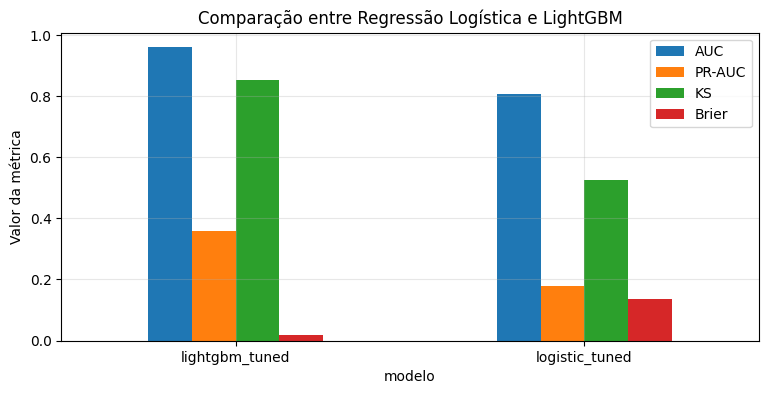

In [ ]:
# -----------------------------------------------------
# 3) Comparação entre modelos
# -----------------------------------------------------
if model_comparison is not None and not model_comparison.empty:
    print("\n===== COMPARAÇÃO ENTRE MODELOS =====")
    display(model_comparison)

    plot_cols = [c for c in ["AUC", "PR-AUC", "KS", "Brier"] if c in model_comparison.columns]
    idx_col = "modelo" if "modelo" in model_comparison.columns else model_comparison.columns[0]

    if plot_cols:
        ax = model_comparison.set_index(idx_col)[plot_cols].plot(kind="bar", figsize=(9, 4))
        ax.set_title("Comparação entre Regressão Logística e LightGBM")
        ax.set_ylabel("Valor da métrica")
        ax.grid(alpha=0.3)
        plt.xticks(rotation=0)
        plt.show()
else:
    print("Comparação entre modelos não disponível.")


## 5. Explicabilidade do LightGBM com SHAP

Se o **LightGBM tunado** estiver disponível, o bloco abaixo estima a contribuição média das features usando **SHAP**, o que fortalece bastante o projeto para portfólio e LinkedIn.

In [ ]:
# Explicabilidade do LightGBM com SHAP
if 'model_results' in globals():
    _model_results_for_shap = model_results
elif 'revised_outputs' in globals():
    _model_results_for_shap = revised_outputs.get("model_results")
else:
    _model_results_for_shap = None

if _model_results_for_shap is not None and "lightgbm_tuned" in _model_results_for_shap:
    shap_outputs = explain_lightgbm_with_shap(
        model_results=_model_results_for_shap,
        train_base=train_base if 'train_base' in globals() else revised_outputs["train_base"],
        top_n=15,
        sample_size=1000,
    )
else:
    print("Execute o fluxo de modelagem antes para gerar explicabilidade com SHAP.")

Execute o fluxo de modelagem antes para gerar explicabilidade com SHAP.


In [ ]:
# -----------------------------------------------------
# 4) Relatório da política (validação)
# -----------------------------------------------------
if policy_report is not None:
    print("\n===== RELATÓRIO DA POLÍTICA (VALIDAÇÃO) =====")
    display(policy_report)
else:
    print("Relatório da política não disponível.")

if bucket_report is not None:
    print("\n===== BUCKETS DE PD (VALIDAÇÃO) =====")
    display(bucket_report)



===== RELATÓRIO DA POLÍTICA (VALIDAÇÃO) =====


,decisao_credito,qtd_contratos,pd_media,bad_rate_observada,expected_loss_medio,expected_loss_total,valor_credito_medio
0,aprovar,19335,0.007308,0.004293,0.003654,70.649702,1.0
1,aprovar_com_ajuste,1,0.092055,0.000000,0.046028,0.046028,1.0
2,rejeitar,2148,0.214108,0.213687,0.107054,229.951886,1.0



===== BUCKETS DE PD (VALIDAÇÃO) =====


,qtd,pd_min,pd_max,pd_media,bad_rate_observada
0,2179,0.002652,0.002720,0.002702,0.000000
1,2119,0.002720,0.002738,0.002728,0.000000
2,2197,0.002738,0.002757,0.002748,0.000000
3,2104,0.002757,0.002782,0.002769,0.000000
4,2144,0.002782,0.002808,0.002796,0.000000
5,2147,0.002808,0.002840,0.002823,0.000000
6,2149,0.002840,0.002898,0.002864,0.000000
7,2149,0.002899,0.003270,0.003043,0.000000
8,2147,0.003270,0.091991,0.043323,0.038659
9,2149,0.092055,0.870218,0.214051,0.213588


In [ ]:
# -----------------------------------------------------
# 5) Amostra da submissão
# -----------------------------------------------------
if submissao is not None:
    print("\n===== AMOSTRA DA SUBMISSÃO =====")
    display(submissao.head())
else:
    print("Submissão principal não disponível.")

if submissao_full is not None and "modelo_utilizado" in submissao_full.columns:
    display(submissao_full[["modelo_utilizado", "target_modelado"]].head(1))



===== AMOSTRA DA SUBMISSÃO =====


,id_cliente,probabilidade_inadimplencia
0,100023,0.002753
1,100031,0.002837
2,100056,0.002813
3,100069,0.002795
4,100085,0.002753


,modelo_utilizado,target_modelado
0,lightgbm_tuned,target_fpd



===== QUANTIS DA PD NA SUBMISSÃO =====


,probabilidade_inadimplencia
count,40000.000000
mean,0.002800
std,0.000048
min,0.002686
50%,0.002803
70%,0.002828
80%,0.002840
90%,0.002852
95%,0.002872
99%,0.002921


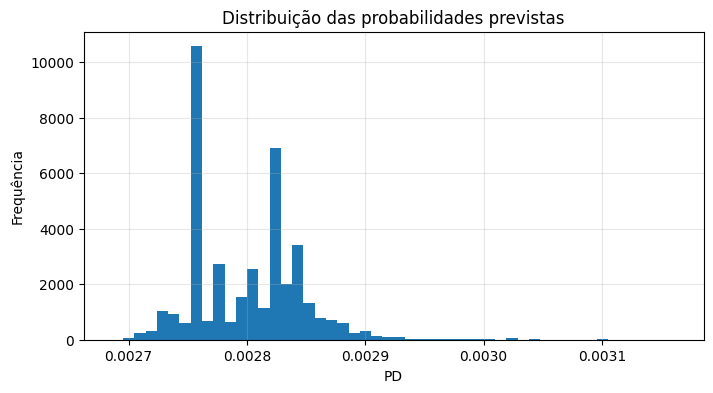

In [ ]:
# -----------------------------------------------------
# 6) Distribuição da PD
# -----------------------------------------------------
if submissao is not None and "probabilidade_inadimplencia" in submissao.columns:
    print("\n===== QUANTIS DA PD NA SUBMISSÃO =====")
    display(
        submissao["probabilidade_inadimplencia"]
        .describe(percentiles=[0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999])
        .to_frame("probabilidade_inadimplencia")
    )

    plt.figure(figsize=(8, 4))
    plt.hist(submissao["probabilidade_inadimplencia"], bins=50)
    plt.title("Distribuição das probabilidades previstas")
    plt.xlabel("PD")
    plt.ylabel("Frequência")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Distribuição da PD não disponível.")



===== DISTRIBUIÇÃO POR DECISÃO DE CRÉDITO =====


,proporcao
decisao_credito,
aprovar,1.0


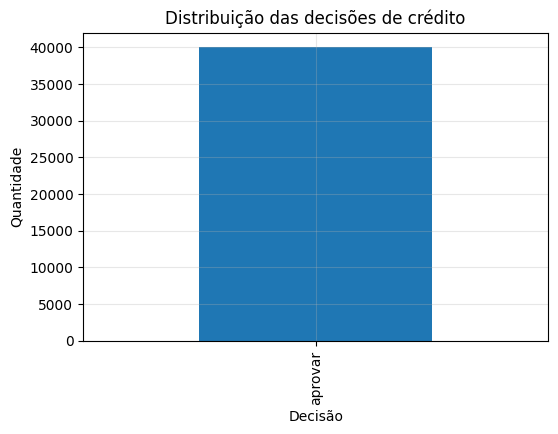

In [ ]:
# -----------------------------------------------------
# 7) Distribuição por decisão de crédito
# -----------------------------------------------------
if submissao_full is not None and "decisao_credito" in submissao_full.columns:
    print("\n===== DISTRIBUIÇÃO POR DECISÃO DE CRÉDITO =====")
    display(
        submissao_full["decisao_credito"]
        .value_counts(normalize=True)
        .rename("proporcao")
        .to_frame()
    )

    plt.figure(figsize=(6, 4))
    submissao_full["decisao_credito"].value_counts().plot(kind="bar")
    plt.title("Distribuição das decisões de crédito")
    plt.xlabel("Decisão")
    plt.ylabel("Quantidade")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Decisões de crédito não disponíveis na submissão enriquecida.")


In [ ]:
# -----------------------------------------------------
# 8) PD média por decisão (sanity check)
# -----------------------------------------------------
if submissao_full is not None and "decisao_credito" in submissao_full.columns:
    print("\n===== PD MÉDIA POR DECISÃO =====")
    display(
        submissao_full.groupby("decisao_credito")["probabilidade_inadimplencia"]
        .mean()
        .to_frame("pd_media")
    )



===== PD MÉDIA POR DECISÃO =====


,pd_media
decisao_credito,
aprovar,0.0028


In [ ]:
# -----------------------------------------------------
# 9) análise da grade de cutoffs e política aplicada
# -----------------------------------------------------
if run_summary is not None and "cutoff_approve" in run_summary and "cutoff_adjust" in run_summary:
    print(f"Cutoff aprovação: {run_summary['cutoff_approve']:.6f}")
    print(f"Cutoff ajuste:    {run_summary['cutoff_adjust']:.6f}")

if cutoff_grid is not None:
    print("\n===== MELHORES COMBINAÇÕES DE CUT-OFFS =====")
    sort_cols = [c for c in ["taxa_aprovacao_total", "expected_loss_total"] if c in cutoff_grid.columns]
    if sort_cols:
        asc = [False, True][:len(sort_cols)]
        top_cutoffs = cutoff_grid.sort_values(sort_cols, ascending=asc).head(10)
    else:
        top_cutoffs = cutoff_grid.head(10)
    display(top_cutoffs)


Cutoff aprovação: 0.091991
Cutoff ajuste:    0.092055

===== MELHORES COMBINAÇÕES DE CUT-OFFS =====


,cutoff_approve,cutoff_adjust,taxa_aprovacao_total,taxa_aprovacao_plena,taxa_aprovacao_ajustada,taxa_rejeicao,bad_rate_aprovados_total,bad_rate_aprovacao_plena,bad_rate_aprovacao_ajustada,bad_rate_rejeitados,expected_loss_total,expected_loss_medio_aprovados,ead_total_aprovada
18,0.002710,0.167309,0.949963,0.051713,0.898250,0.050037,0.011466,0.0,0.012126,0.286512,97.495791,0.004777,14619.6
36,0.002720,0.167309,0.949963,0.101424,0.848538,0.050037,0.011466,0.0,0.012836,0.286512,97.930652,0.004798,14940.0
53,0.002728,0.167309,0.949963,0.151415,0.798548,0.050037,0.011466,0.0,0.013640,0.286512,98.369537,0.004820,15262.2
69,0.002738,0.167309,0.949963,0.200056,0.749907,0.050037,0.011466,0.0,0.014524,0.286512,98.797884,0.004841,15575.7
84,0.002748,0.167309,0.949963,0.250000,0.699963,0.050037,0.011466,0.0,0.015561,0.286512,99.239328,0.004863,15897.6
98,0.002757,0.167309,0.949963,0.302318,0.647645,0.050037,0.011466,0.0,0.016818,0.286512,99.703505,0.004885,16234.8
111,0.002769,0.167309,0.949963,0.350028,0.599935,0.050037,0.011466,0.0,0.018155,0.286512,100.128306,0.004906,16542.3
123,0.002782,0.167309,0.949963,0.400251,0.549711,0.050037,0.011466,0.0,0.019814,0.286512,100.577518,0.004928,16866.0
134,0.002797,0.167309,0.949963,0.450009,0.499953,0.050037,0.011466,0.0,0.021786,0.286512,101.024736,0.004950,17186.7
144,0.002808,0.167309,0.949963,0.500047,0.449916,0.050037,0.011466,0.0,0.024209,0.286512,101.476656,0.004972,17509.2


## 6. Proposta de melhoria da política de crédito

Como evolução da política inicial, a recomendação é calibrar os cortes com base na **distribuição observada do score**.

In [ ]:
# Recalibração / aplicação da política com cutoffs já definidos na validação
submissao = safe_read_csv(OUTPUT_DIR / "submissao_case.csv")
run_summary = safe_load_json(OUTPUT_DIR / "run_summary.json")

if submissao is not None and run_summary is not None:
    cutoff_approve = run_summary["cutoff_approve"]
    cutoff_adjust = run_summary["cutoff_adjust"]

    print(f"Cutoff aprovação: {cutoff_approve:.6f}")
    print(f"Cutoff ajuste:    {cutoff_adjust:.6f}")

    def politica_cutoffs(pd_hat: float, c1: float, c2: float) -> str:
        if pd_hat <= c1:
            return "aprovar"
        elif pd_hat <= c2:
            return "aprovar_com_ajuste"
        return "rejeitar"

    submissao["decisao_credito"] = submissao["probabilidade_inadimplencia"].apply(
        lambda x: politica_cutoffs(x, cutoff_approve, cutoff_adjust)
    )

    display(submissao["decisao_credito"].value_counts().to_frame("qtd"))
    display(
        submissao.groupby("decisao_credito")["probabilidade_inadimplencia"]
        .mean()
        .to_frame("pd_media")
    )
else:
    print("Não foi possível recalibrar a política: outputs ausentes.")


Cutoff aprovação: 0.091991
Cutoff ajuste:    0.092055


,qtd
decisao_credito,
aprovar,40000


,pd_media
decisao_credito,
aprovar,0.0028


In [ ]:
# Política alternativa exploratória baseada em percentis da distribuição de risco
submissao = safe_read_csv(OUTPUT_DIR / "submissao_case.csv")

if submissao is not None:
    p70 = submissao["probabilidade_inadimplencia"].quantile(0.70)
    p90 = submissao["probabilidade_inadimplencia"].quantile(0.90)

    if p90 <= p70:
        p90 = float(np.nextafter(p70, np.inf))

    print(f"Corte P70: {p70:.6f}")
    print(f"Corte P90: {p90:.6f}")

    def politica_percentil(pd_hat: float, p70: float, p90: float) -> str:
        if pd_hat <= p70:
            return "aprovar"
        elif pd_hat <= p90:
            return "aprovar_com_ajuste"
        return "rejeitar"

    submissao["decisao_percentil"] = submissao["probabilidade_inadimplencia"].apply(
        lambda x: politica_percentil(x, p70, p90)
    )

    display(submissao["decisao_percentil"].value_counts().to_frame("qtd"))
    display(
        submissao.groupby("decisao_percentil")["probabilidade_inadimplencia"]
        .agg(["min", "mean", "max", "count"])
    )
else:
    print("Submissão não disponível para análise por percentis.")


Corte P70: 0.002828
Corte P90: 0.002852


,qtd
decisao_percentil,
aprovar,29876
aprovar_com_ajuste,6314
rejeitar,3810


,min,mean,max,count
decisao_percentil,,,,
aprovar,0.002686,0.002780,0.002828,29876
aprovar_com_ajuste,0.002828,0.002842,0.002852,6314
rejeitar,0.002852,0.002886,0.003162,3810


# 📊 Conclusão

Este projeto teve como objetivo desenvolver um pipeline completo de modelagem de risco de crédito, indo além da previsão de inadimplência e focando na construção de uma política de decisão aplicável ao negócio.

---

## 🎯 Principais resultados

### 1. Definição de target orientada por dados

Em vez de assumir uma definição padrão de inadimplência, foram testadas múltiplas alternativas (FPD, EVER15, EVER30, OVER60), com seleção baseada em:

- cobertura da base  
- estabilidade temporal (por safra)  
- capacidade preditiva  

Essa abordagem permitiu escolher um target mais adequado ao comportamento da carteira.

---

### 2. Modelagem e comparação de abordagens

Foram avaliados dois tipos de modelos:

- Regressão Logística (baseline interpretável)  
- LightGBM (modelo não linear com maior capacidade de captura de interações)  

A avaliação foi feita com validação temporal (out-of-time), utilizando:

- AUC  
- PR-AUC  
- KS  
- Brier Score  

O modelo final foi selecionado com base em desempenho em validação, garantindo robustez fora da amostra.

---

### 3. Política de crédito baseada em evidência

Um dos principais diferenciais do projeto foi a construção de uma política de crédito a partir dos dados.

Em vez de utilizar cortes arbitrários de probabilidade, os thresholds foram definidos com base na relação entre:

- probabilidade estimada (PD)  
- inadimplência observada na validação  

Isso permitiu transformar o modelo em uma decisão prática:

- Aprovar  
- Aprovar com ajuste  
- Rejeitar  

---

### 4. Interpretação dos resultados

A análise revelou um ponto importante:

> A distribuição da probabilidade de inadimplência apresentou baixa dispersão, o que indica limitação na granularidade do modelo para separar níveis intermediários de risco.

Como consequência, observou-se dificuldade em definir uma faixa intermediária bem delimitada na política de crédito.

Esse resultado sugere duas possibilidades:

- necessidade de enriquecimento de features  
- ou estrutura de risco da carteira mais binária (baixo vs alto risco)

---

### 5. Explicabilidade do modelo

Foi utilizada a abordagem SHAP para interpretar o modelo e identificar as variáveis mais relevantes para a previsão de inadimplência.

Essa etapa é essencial para:

- validar consistência do modelo  
- aumentar confiança na aplicação prática  
- apoiar decisões de negócio  

---

## 💡 Principais aprendizados

- Modelar risco é importante, mas transformar o modelo em decisão é o que gera valor  
- A escolha do target tem impacto direto na qualidade do modelo  
- Validação temporal é essencial em problemas de crédito  
- Nem sempre o modelo permite uma segmentação perfeita — e isso também é um insight relevante  

---

## 🚀 Próximos passos

- Enriquecimento de features com variáveis comportamentais e temporais  
- Teste de modelos adicionais (ex: XGBoost, CatBoost)  
- Refinamento da política com base em métricas econômicas (expected loss)  
- Monitoramento de drift e estabilidade do modelo ao longo do tempo  

---

## 🏁 Conclusão

Este projeto demonstra a construção de um pipeline completo de risco de crédito, com foco em:

- robustez estatística  
- interpretabilidade  
- aplicabilidade em decisão  

> O principal valor não está apenas em prever inadimplência, mas em estruturar como agir sobre o risco identificado.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import nbformat

input_path = "/content/Analise_de_Risco_de_Credito_Completo.ipynb"
output_path = "/content/Analise_de_Risco_de_Credito_Completo_clean.ipynb"

nb = nbformat.read(input_path, as_version=4)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, output_path)

from google.colab import files
files.download(output_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Analise_de_Risco_de_Credito_Completo.ipynb'